# Exploration des données : BirdCLEF+ 2026

Analyse exploratoire du dataset Kaggle BirdCLEF+ 2026, préalable à toute modélisation. L'objectif est de caractériser le dataset (volume, équilibre des classes, propriétés audio, écart entre les fichiers focaux d'entraînement et les soundscapes de test) et d'en tirer les contraintes qui structureront la suite du projet.


## Section 0. Chargement et premières vérifications

Lecture des quatre fichiers CSV du dataset, contrôle de leur intégrité et mise en place du contexte graphique commun (palette par classe taxonomique, thème seaborn). La correspondance entre les codes d'espèces de `taxonomy.csv` et les colonnes de `sample_submission.csv` est vérifiée explicitement : si elle n'est pas parfaite, toute la chaîne de modélisation repose sur une hypothèse fausse.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa

# Chemins du projet (centralisés dans src/config.py).
sys.path.insert(0, str(Path.cwd().parent))
from src import config

# Couleurs par classe taxonomique, réutilisées dans l'ensemble du notebook.
PALETTE_CLASSES = {
    "Aves":     "#0072B2",
    "Amphibia": "#009E73",
    "Mammalia": "#D55E00",
    "Insecta":  "#E69F00",
    "Reptilia": "#CC79A7",
}

sns.set_theme(
    context="notebook",
    style="whitegrid",
    rc={
        "figure.figsize": (12, 6),
        "figure.dpi": 110,
        "savefig.dpi": 150,
        "axes.titleweight": "bold",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "grid.alpha": 0.3,
    },
)

print("pandas  :", pd.__version__)
print("numpy   :", np.__version__)
print("librosa :", librosa.__version__)

pandas  : 2.2.2
numpy   : 1.26.4
librosa : 0.10.2.post1


In [2]:
train_df       = pd.read_csv(config.TRAIN_CSV)
taxonomy_df    = pd.read_csv(config.TAXONOMY_CSV)
soundscapes_df = pd.read_csv(config.SOUNDSCAPE_LABELS_CSV)
submission_df  = pd.read_csv(config.SAMPLE_SUBMISSION_CSV)

print(f"train.csv             : {train_df.shape}")
print(f"taxonomy.csv          : {taxonomy_df.shape}")
print(f"soundscape labels     : {soundscapes_df.shape}")
print(f"sample_submission.csv : {submission_df.shape}")

train.csv             : (35549, 15)
taxonomy.csv          : (234, 5)
soundscape labels     : (1478, 4)
sample_submission.csv : (3, 235)


In [3]:
# Valeurs manquantes dans train.csv
nan_counts = train_df.isna().sum()
nan_counts = nan_counts[nan_counts > 0]
if nan_counts.empty:
    print("train.csv : aucune valeur manquante sur toutes les colonnes.")
else:
    print("Colonnes avec valeurs manquantes :")
    print(nan_counts.to_string())

# Cohérence entre la liste des espèces de taxonomy.csv et les colonnes attendues
# dans sample_submission.csv. Une divergence ici fausserait toute la soumission.
taxo_labels     = set(taxonomy_df["primary_label"])
submission_cols = set(submission_df.columns) - {"row_id"}

manque_dans_sub  = taxo_labels - submission_cols
manque_dans_taxo = submission_cols - taxo_labels

print()
print(f"Codes d'espèces dans taxonomy.csv          : {len(taxo_labels)}")
print(f"Colonnes d'espèces dans sample_submission  : {len(submission_cols)}")
print(f"Codes présents dans taxonomy mais pas dans submission : {len(manque_dans_sub)}")
print(f"Codes présents dans submission mais pas dans taxonomy : {len(manque_dans_taxo)}")

train.csv : aucune valeur manquante sur toutes les colonnes.

Codes d'espèces dans taxonomy.csv          : 234
Colonnes d'espèces dans sample_submission  : 234
Codes présents dans taxonomy mais pas dans submission : 0
Codes présents dans submission mais pas dans taxonomy : 0


In [4]:
print("train.csv")
display(train_df.head())

print("\ntaxonomy.csv")
display(taxonomy_df.head())

print("\ntrain_soundscapes_labels.csv")
display(soundscapes_df.head())

print("\nsample_submission.csv (6 premières colonnes)")
display(submission_df.iloc[:, :6].head())

train.csv


,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,class_name,inat_taxon_id,author,license,rating,url,filename,collection
0,1161364,[],[],-22.7562,-46.8666,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1216197....,1161364/iNat1216197.ogg,iNat
1,1161364,[],[],-22.7558,-46.8700,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1114648....,1161364/iNat1114648.ogg,iNat
2,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/810195.m...,1161364/iNat810195.ogg,iNat
3,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/818781.m...,1161364/iNat818781.ogg,iNat
4,1161364,[],[],-22.7426,-46.8985,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/556514.m...,1161364/iNat556514.ogg,iNat



taxonomy.csv


,primary_label,inat_taxon_id,scientific_name,common_name,class_name
0,1161364,1161364,Guyalna cuta,Guyalna cuta,Insecta
1,116570,116570,Caiman yacare,Southern Spectacled Caiman,Reptilia
2,1176823,1176823,Leptodactylus luctator,Wrestler Frog,Amphibia
3,1491113,1491113,Adenomera guarani,Guaraní leaf-litter frog,Amphibia
4,1595929,1595929,Lysapsus limellum,Uruguay Harlequin Frog,Amphibia



train_soundscapes_labels.csv


,filename,start,end,primary_label
0,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:00,00:00:05,22961;23158;24321;517063;65380
1,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:05,00:00:10,22961;23158;24321;517063;65380
2,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:10,00:00:15,22961;23158;24321;517063;65380
3,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:15,00:00:20,22961;23158;24321;517063;65380
4,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:20,00:00:25,22961;23158;24321;517063;65380



sample_submission.csv (6 premières colonnes)


,row_id,1161364,116570,1176823,1491113,1595929
0,BC2026_Test_0001_S05_20250227_010002_5,0.004274,0.004274,0.004274,0.004274,0.004274
1,BC2026_Test_0001_S05_20250227_010002_10,0.004274,0.004274,0.004274,0.004274,0.004274
2,BC2026_Test_0001_S05_20250227_010002_15,0.004274,0.004274,0.004274,0.004274,0.004274


### Observation Section 0

- 35 549 enregistrements focaux pour 234 espèces, soit environ 152 fichiers par espèce en moyenne. La distribution réelle est probablement très déséquilibrée et sera analysée en détail en Section 2.
- Aucune valeur manquante dans `train.csv` sur ses 35 549 lignes et 15 colonnes. Aucune stratégie d'imputation n'est requise sur les métadonnées.
- Correspondance exacte entre les 234 codes de `taxonomy.csv` et les 234 colonnes (hors `row_id`) de `sample_submission.csv`. Le format de soumission est obtenu directement en indexant un DataFrame de probabilités par ces codes.
- Les `primary_label` sont des codes (eBird pour les oiseaux, identifiants iNaturalist pour les autres classes) et non des noms d'espèces. Toute analyse par espèce nécessite une jointure avec `taxonomy.csv` pour obtenir `scientific_name`, `common_name` ou `class_name`.
- La colonne `secondary_labels` est stockée sous forme de chaîne ressemblant à une liste Python (`"[]"`, `"['xyz']"`). Un parsing avec `ast.literal_eval` sera nécessaire pour exploiter son contenu en Section 2.
- `sample_submission.csv` ne contient que 3 lignes en local, avec toutes les probabilités initialisées à 1/234 ≈ 0.00427. Il s'agit d'un placeholder ; le véritable jeu de test (environ 600 fichiers) n'est révélé qu'au moment d'une soumission Kaggle, ce qui reste sans impact dans le cadre de ce projet.
- `train_soundscapes_labels.csv` est multi-label par construction : sa colonne `primary_label` est une liste de codes d'espèces séparés par `;`. Le premier exemple observé contient cinq espèces simultanées sur une fenêtre de cinq secondes. Le caractère multi-label du problème n'est donc pas un choix de modélisation mais une propriété imposée par les données.

## Section 1. Composition taxonomique du dataset

Caractérisation des 234 espèces cibles sur cinq dimensions : leur répartition entre classes taxonomiques, la diversité phylogénétique sous-jacente (genres comportant plusieurs espèces), la couverture par les données focales versus uniquement par les annotations de soundscapes, la proportion de sonotypes non identifiés à l'espèce, et la cohérence entre classe taxonomique et source d'origine (Xeno-Canto versus iNaturalist). Chaque sous-analyse établit une conséquence directe pour la modélisation, regroupée dans l'observation finale.

In [5]:
# Construction d'un DataFrame `species_df` qui enrichit `taxonomy_df` avec :
#   - le genre (extrait du nom scientifique),
#   - le nombre d'enregistrements focaux par espèce,
#   - le nombre de fenêtres soundscape annotées contenant l'espèce,
#   - un flag indiquant les sonotypes,
#   - les comptes par collection (XC, iNat).
# Ce DataFrame est utilisé dans toutes les sous-analyses de la section.

train_df['primary_label']    = train_df['primary_label'].astype(str)
taxonomy_df['primary_label'] = taxonomy_df['primary_label'].astype(str)

focal_counts = train_df['primary_label'].value_counts()

soundscape_explode = (
    soundscapes_df['primary_label']
    .str.split(';')
    .explode()
    .str.strip()
)
soundscape_counts = soundscape_explode.value_counts()

collection_per_species = (
    train_df.groupby(['primary_label', 'collection'])
    .size()
    .unstack(fill_value=0)
    .rename(columns={'XC': 'n_xc', 'iNat': 'n_inat'})
)
for col in ('n_xc', 'n_inat'):
    if col not in collection_per_species.columns:
        collection_per_species[col] = 0

species_df = taxonomy_df.copy()
species_df['genus']        = species_df['scientific_name'].str.split().str[0]
species_df['n_focal']      = species_df['primary_label'].map(focal_counts).fillna(0).astype(int)
species_df['n_sound_win']  = species_df['primary_label'].map(soundscape_counts).fillna(0).astype(int)
species_df['is_sonotype']  = species_df['primary_label'].str.contains('son', case=False, regex=False)
species_df = species_df.join(collection_per_species, on='primary_label').fillna({'n_xc': 0, 'n_inat': 0})
species_df['n_xc']   = species_df['n_xc'].astype(int)
species_df['n_inat'] = species_df['n_inat'].astype(int)

species_df.head()

,primary_label,inat_taxon_id,scientific_name,common_name,class_name,genus,n_focal,n_sound_win,is_sonotype,n_xc,n_inat
0,1161364,1161364,Guyalna cuta,Guyalna cuta,Insecta,Guyalna,11,0,False,0,11
1,116570,116570,Caiman yacare,Southern Spectacled Caiman,Reptilia,Caiman,1,26,False,0,1
2,1176823,1176823,Leptodactylus luctator,Wrestler Frog,Amphibia,Leptodactylus,12,0,False,0,12
3,1491113,1491113,Adenomera guarani,Guaraní leaf-litter frog,Amphibia,Adenomera,0,158,False,0,0
4,1595929,1595929,Lysapsus limellum,Uruguay Harlequin Frog,Amphibia,Lysapsus,5,0,False,1,4


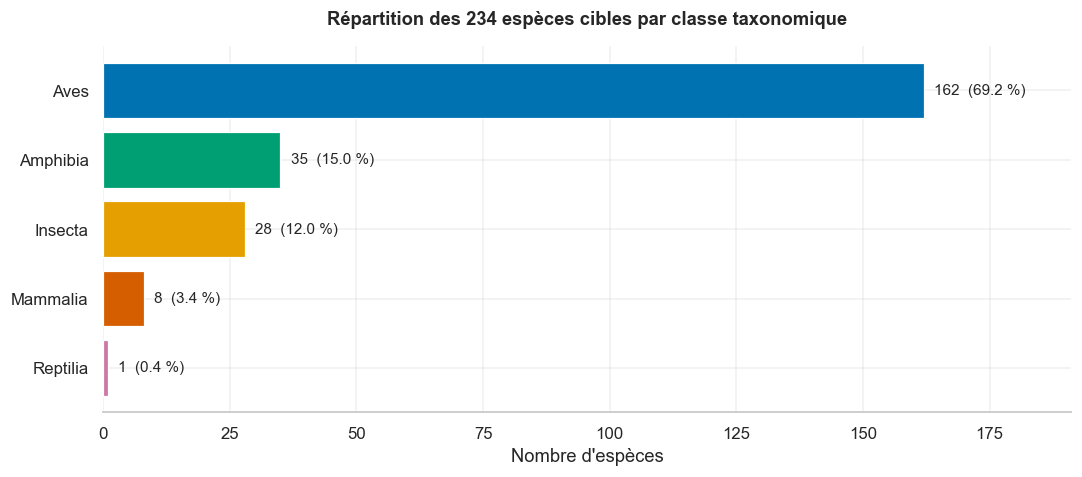

In [6]:
# Figure 1. Répartition des 234 espèces par classe taxonomique.
class_counts = species_df['class_name'].value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 4.5))
colors = [PALETTE_CLASSES[c] for c in class_counts.index]
bars = ax.barh(class_counts.index, class_counts.values, color=colors, edgecolor='white', linewidth=0.8)

total = class_counts.sum()
for bar, val in zip(bars, class_counts.values):
    pct = val / total * 100
    ax.text(val + 2, bar.get_y() + bar.get_height() / 2,
            f'{val}  ({pct:.1f} %)', va='center', fontsize=10)

ax.set_title("Répartition des 234 espèces cibles par classe taxonomique", pad=14)
ax.set_xlabel("Nombre d'espèces")
ax.set_xlim(0, class_counts.max() * 1.18)
ax.tick_params(axis='y', labelsize=11)
sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()

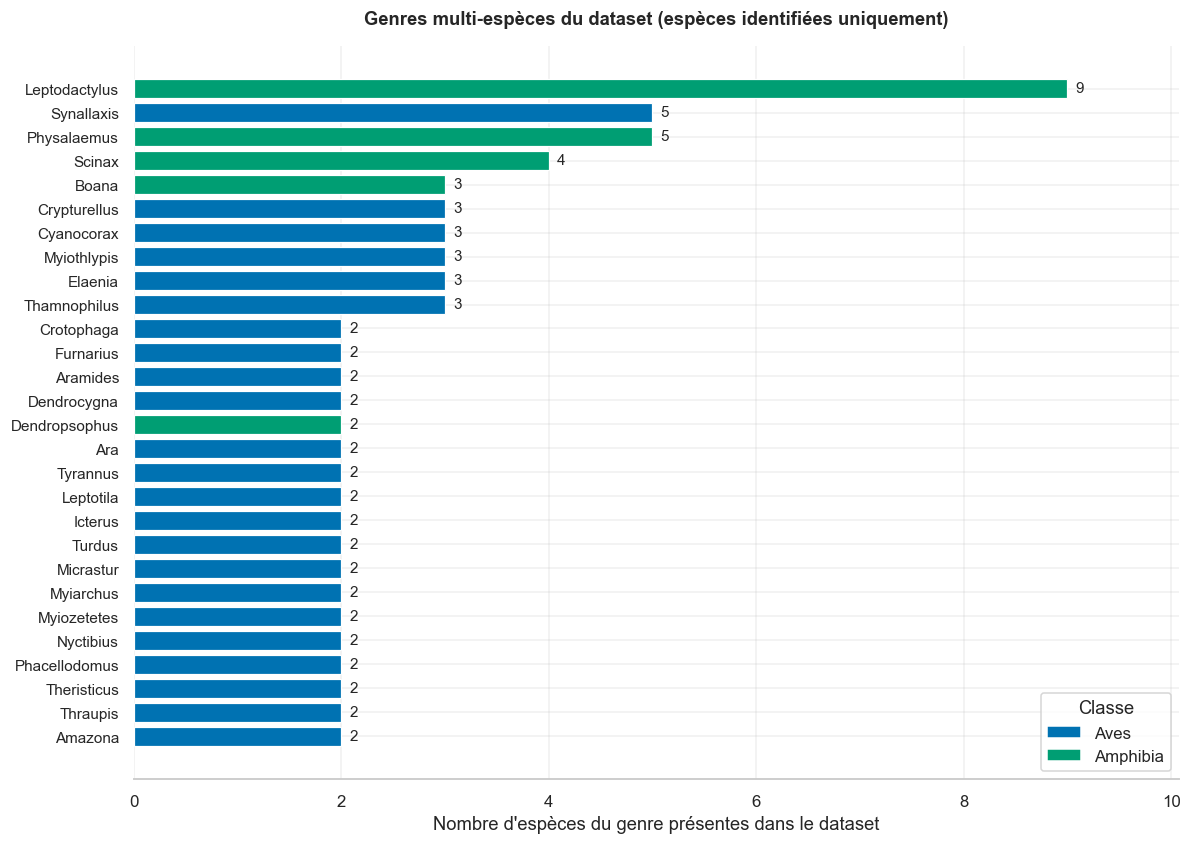

Espèces identifiées (hors sonotypes) : 209
Genres uniques                       : 160
Genres avec au moins 2 espèces       : 28
Espèces appartenant à un genre multi : 77 (36.8 % des identifiées)


In [7]:
# Figure 2. Diversité phylogénétique : genres comportant au moins deux espèces dans le dataset.
# Les sonotypes sont exclus (pseudo-genre "Insect" générique, non-phylogénétique).
identified = species_df[~species_df['is_sonotype']].copy()
genus_size  = identified.groupby('genus').size()
genus_class = identified.groupby('genus')['class_name'].first()

multi_genera = genus_size[genus_size >= 2].sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(11, max(5, len(multi_genera) * 0.28)))
colors = [PALETTE_CLASSES[genus_class[g]] for g in multi_genera.index]
bars = ax.barh(multi_genera.index, multi_genera.values, color=colors, edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, multi_genera.values):
    ax.text(val + 0.08, bar.get_y() + bar.get_height() / 2,
            str(val), va='center', fontsize=10)

ax.set_title("Genres multi-espèces du dataset (espèces identifiées uniquement)", pad=14)
ax.set_xlabel("Nombre d'espèces du genre présentes dans le dataset")
ax.tick_params(axis='y', labelsize=10)

from matplotlib.patches import Patch
classes_present = sorted({genus_class[g] for g in multi_genera.index},
                         key=lambda c: list(PALETTE_CLASSES).index(c))
legend_elements = [Patch(facecolor=PALETTE_CLASSES[c], label=c) for c in classes_present]
ax.legend(handles=legend_elements, loc='lower right', frameon=True, title="Classe")

ax.set_xlim(0, multi_genera.max() * 1.12)
sns.despine(left=True)
plt.tight_layout()
plt.show()

n_total_genera = genus_size.size
n_multi_genera = (genus_size >= 2).sum()
n_species_in_multi = multi_genera.sum()
print(f"Espèces identifiées (hors sonotypes) : {len(identified)}")
print(f"Genres uniques                       : {n_total_genera}")
print(f"Genres avec au moins 2 espèces       : {n_multi_genera}")
print(f"Espèces appartenant à un genre multi : {n_species_in_multi} "
      f"({n_species_in_multi / len(identified) * 100:.1f} % des identifiées)")

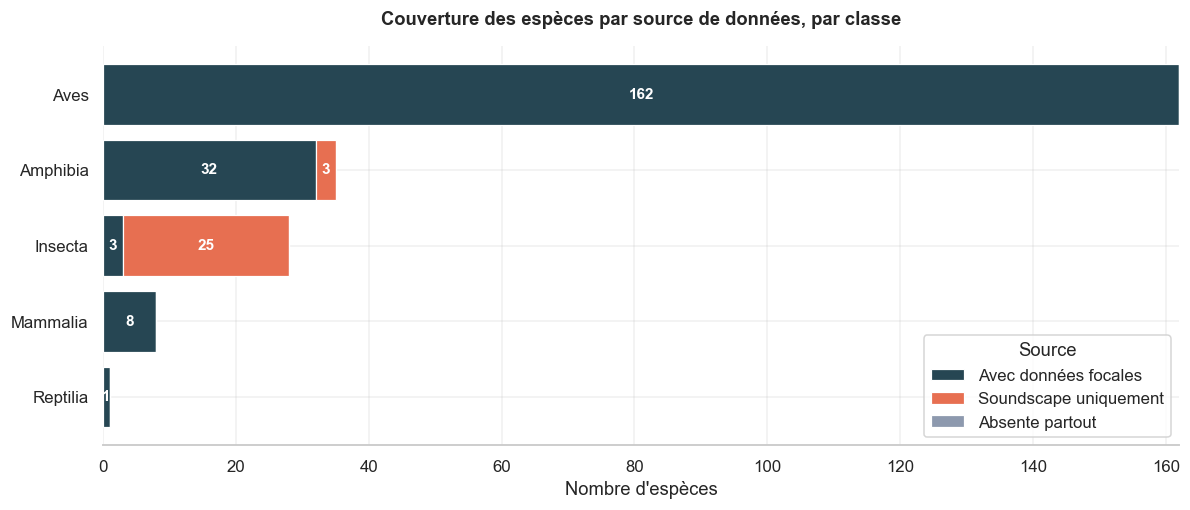

Espèces avec des données focales       : 206
Espèces uniquement en soundscape       : 28
Espèces absentes des deux sources      : 0


In [8]:
# Figure 3. Couverture des espèces par source de données (focal vs soundscape) par classe.
def coverage_status(row):
    if row['n_focal'] > 0:
        return 'avec_focal'
    if row['n_sound_win'] > 0:
        return 'soundscape_seul'
    return 'absente'

species_df['coverage'] = species_df.apply(coverage_status, axis=1)

coverage = (
    species_df.groupby(['class_name', 'coverage'])
    .size()
    .unstack(fill_value=0)
)
for col in ('avec_focal', 'soundscape_seul', 'absente'):
    if col not in coverage.columns:
        coverage[col] = 0
coverage = coverage[['avec_focal', 'soundscape_seul', 'absente']]
coverage = coverage.loc[coverage.sum(axis=1).sort_values(ascending=True).index]

fig, ax = plt.subplots(figsize=(11, 4.8))
colors_cov = {'avec_focal': '#264653',
              'soundscape_seul': '#E76F51',
              'absente': '#8D99AE'}
labels_cov = {'avec_focal': 'Avec données focales',
              'soundscape_seul': 'Soundscape uniquement',
              'absente': 'Absente partout'}

bottom = np.zeros(len(coverage))
for col in ['avec_focal', 'soundscape_seul', 'absente']:
    vals = coverage[col].values
    ax.barh(coverage.index, vals, left=bottom,
            color=colors_cov[col], label=labels_cov[col], edgecolor='white', linewidth=0.8)
    for i, v in enumerate(vals):
        if v > 0:
            ax.text(bottom[i] + v / 2, i, str(v),
                    ha='center', va='center', color='white', fontsize=10, fontweight='bold')
    bottom += vals

ax.set_title("Couverture des espèces par source de données, par classe", pad=14)
ax.set_xlabel("Nombre d'espèces")
ax.tick_params(axis='y', labelsize=11)
ax.legend(loc='lower right', frameon=True, title="Source")
sns.despine(left=True)
plt.tight_layout()
plt.show()

n_focal_only = (species_df['coverage'] == 'avec_focal').sum()
n_sound_only = (species_df['coverage'] == 'soundscape_seul').sum()
n_absent     = (species_df['coverage'] == 'absente').sum()
print(f"Espèces avec des données focales       : {n_focal_only}")
print(f"Espèces uniquement en soundscape       : {n_sound_only}")
print(f"Espèces absentes des deux sources      : {n_absent}")

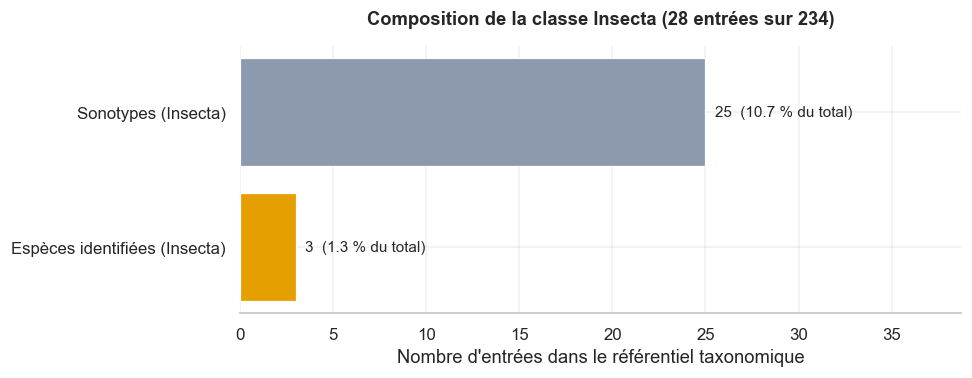

Sonotypes : 25 entrées (10.7 % des 234 classes cibles).
Tous les sonotypes appartiennent à la classe Insecta : True


In [9]:
# Figure 4. Sonotypes versus espèces identifiées dans la classe Insecta.
insecta = species_df[species_df['class_name'] == 'Insecta']
n_id   = (~insecta['is_sonotype']).sum()
n_sono = insecta['is_sonotype'].sum()
n_total_classes = len(species_df)

fig, ax = plt.subplots(figsize=(9, 3.6))
categories = ['Espèces identifiées (Insecta)', 'Sonotypes (Insecta)']
values     = [n_id, n_sono]
colors_bar = [PALETTE_CLASSES['Insecta'], '#8D99AE']
bars = ax.barh(categories, values, color=colors_bar, edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{val}  ({val / n_total_classes * 100:.1f} % du total)',
            va='center', fontsize=10)

ax.set_title(f"Composition de la classe Insecta ({len(insecta)} entrées sur {n_total_classes})", pad=14)
ax.set_xlabel("Nombre d'entrées dans le référentiel taxonomique")
ax.set_xlim(0, max(values) * 1.55)
sns.despine(left=True)
plt.tight_layout()
plt.show()

print(f"Sonotypes : {n_sono} entrées ({n_sono / n_total_classes * 100:.1f} % des 234 classes cibles).")
print(f"Tous les sonotypes appartiennent à la classe Insecta : "
      f"{(species_df.loc[species_df['is_sonotype'], 'class_name'] == 'Insecta').all()}")

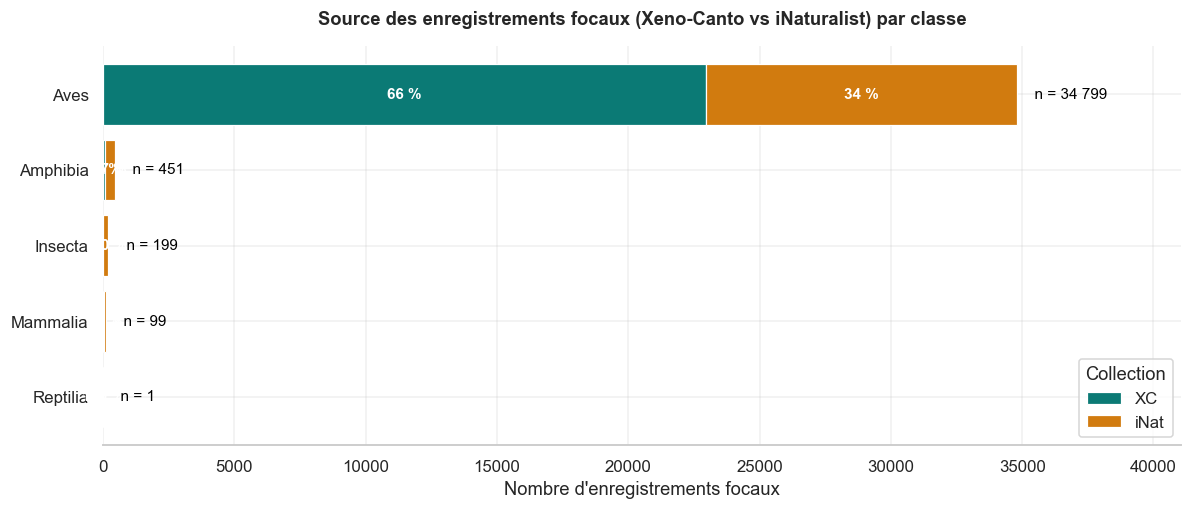

In [10]:
# Figure 5. Répartition des enregistrements focaux par source (XC vs iNat) et par classe.
source = (
    train_df.groupby(['class_name', 'collection'])
    .size()
    .unstack(fill_value=0)
)
for c in ('XC', 'iNat'):
    if c not in source.columns:
        source[c] = 0
source = source[['XC', 'iNat']]
source['total'] = source.sum(axis=1)
source = source.sort_values('total', ascending=True)
totals = source['total']
source = source.drop(columns='total')

fig, ax = plt.subplots(figsize=(11, 4.8))
colors_src = {'XC': '#0B7A75', 'iNat': '#D17B0F'}
bottom = np.zeros(len(source))
for col in ['XC', 'iNat']:
    vals = source[col].values
    ax.barh(source.index, vals, left=bottom,
            color=colors_src[col], label=col, edgecolor='white', linewidth=0.8)
    for i, v in enumerate(vals):
        if v > 0:
            pct = v / totals.values[i] * 100
            ax.text(bottom[i] + v / 2, i, f'{pct:.0f} %',
                    ha='center', va='center', color='white', fontsize=10, fontweight='bold')
    bottom += vals

# Annotation du total à droite de chaque barre.
for i, t in enumerate(totals.values):
    ax.text(t + totals.max() * 0.01, i, f'  n = {t:,}'.replace(',', ' '),
            va='center', fontsize=10, color='black')

ax.set_title("Source des enregistrements focaux (Xeno-Canto vs iNaturalist) par classe", pad=14)
ax.set_xlabel("Nombre d'enregistrements focaux")
ax.tick_params(axis='y', labelsize=11)
ax.set_xlim(0, totals.max() * 1.18)
ax.legend(loc='lower right', frameon=True, title="Collection")
sns.despine(left=True)
plt.tight_layout()
plt.show()

### Observation Section 1

- **Composition très déséquilibrée entre classes taxonomiques.** Les Aves dominent largement (162 espèces, 69,2 %), suivis par Amphibia (35, 15,0 %), Insecta (28, 12,0 %), Mammalia (8, 3,4 %) et Reptilia (1, 0,4 %). Conséquence modélisation : la performance globale (macro-AUC) sera mécaniquement dominée par les Aves. Il faudra rapporter les performances ventilées par classe pour ne pas masquer une faiblesse sur les classes minoritaires. La classe Reptilia, avec une seule espèce, sera particulièrement fragile à toute analyse comparative.

- **Diversité phylogénétique : 209 espèces identifiées dans 160 genres, dont 28 genres comportent au moins deux espèces.** Ces 28 genres contiennent 77 espèces, soit 36,8 % des espèces identifiées. Les genres les plus chargés sont `Leptodactylus` (9 espèces, Amphibia), `Physalaemus` (5, Amphibia), `Synallaxis` (5, Aves), `Scinax` (4, Amphibia). Conséquence modélisation : les espèces du même genre ont des vocalisations acoustiquement proches, ce qui constitue un risque de confusion important. Ces paires intra-genre seront ciblées en priorité dans l'analyse d'erreurs, et l'introduction de features capturant des structures spectrales fines (formants, modulations) pourra être justifiée par cette diversité réelle restreinte.

- **Couverture asymétrique focal versus soundscape.** 206 espèces ont au moins un enregistrement focal, mais 28 n'apparaissent que dans les soundscapes annotés. Ces 28 cas se concentrent presque exclusivement sur Insecta (25 espèces sans focal) et marginalement sur Amphibia (3 espèces). Conséquence modélisation : un classifieur entraîné uniquement sur le focal ignorera de fait 12 % des classes cibles. Trois options se présentent : exclure ces espèces de l'entraînement et accepter une prédiction toujours à zéro pour elles, exploiter les annotations soundscape comme données d'entraînement (peu de données par espèce, multi-label intrinsèque), ou recourir à un modèle pré-entraîné figé qui aurait pu déjà rencontrer ces espèces. Cette décision est centrale pour la suite et sera explicitement justifiée dans le rapport.

- **Sonotypes : 25 entrées sur 234 (10,7 %), toutes en Insecta.** Sur les 28 entrées Insecta du référentiel, 25 sont en réalité des sonotypes (`47158sonNN`, identifiant générique iNaturalist Cicadidae) et seules 3 sont des espèces identifiées au niveau spécifique. Conséquence modélisation : ces 25 codes ne portent aucune information taxonomique exploitable. On ne peut pas leur prêter de voisin phylogénétique, et leur poids dans la macro-AUC (1/234 chacun, soit 10,7 % au total) impose qu'on ne les traite pas comme du bruit. Étant majoritairement sans données focales, ils dépendent presque entièrement des annotations soundscape, ce qui les place tout en haut de la liste des classes difficiles.

- **Collinéarité forte entre classe taxonomique et collection source.** Les Aves se répartissent à 66 % sur Xeno-Canto et 34 % sur iNaturalist (seule classe vraiment mixte), tandis qu'Amphibia est à 87 % iNat, Mammalia à 67 % iNat, et Insecta et Reptilia à 100 % iNat. Conséquence modélisation : si on observe ensuite des différences de qualité audio ou de niveau de bruit entre XC et iNat, ces différences seront automatiquement collinéaires avec la classe taxonomique et il faudra démêler les deux effets. Concrètement, une éventuelle baisse de performance sur les Insecta ne sera pas attribuable mécaniquement à « la classe est difficile » : il pourra aussi s'agir d'un biais d'origine d'enregistrement (microphones iNaturalist, conditions de captation). Ce point sera ré-examiné en Section 4 lorsqu'on caractérisera les propriétés audio par collection.

## Section 2. Métadonnées focales et qualité d'enregistrement

Analyse détaillée de `train.csv`. Six dimensions sont examinées : le déséquilibre par espèce (et sa quantification via le coefficient de Gini), la distribution du `rating` de qualité, les types de vocalisation déclarés, la présence d'espèces secondaires dans le focal, la concentration des contributions par auteur, et la répartition des licences. L'objectif est d'identifier les biais et hétérogénéités du dataset qui devront être pris en compte dans les choix de prétraitement, de filtrage et surtout de validation.

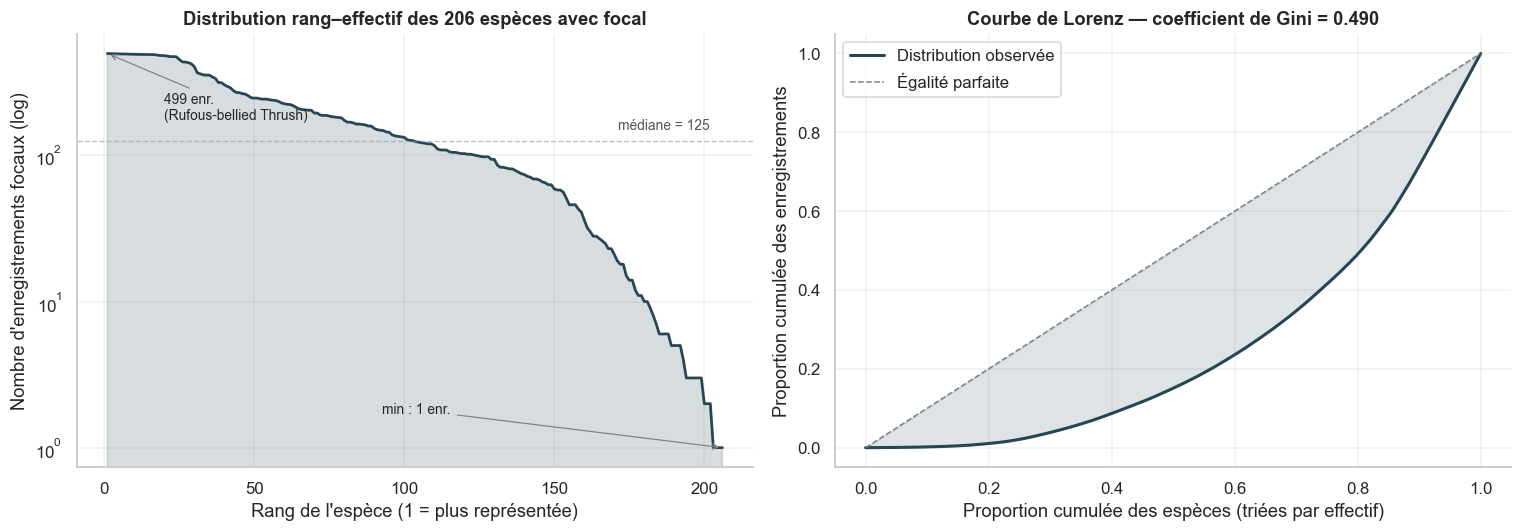

Espèces avec au moins un enregistrement focal : 206
Coefficient de Gini (concentration)           : 0.490
Espèces avec moins de 10 enregistrements      : 25
Espèces avec moins de 5 enregistrements       : 14
Espèces avec exactement 1 enregistrement      : 4

Top 5 espèces les plus représentées :
    499  rubthr1     Rufous-bellied Thrush  (Aves)
    498  banana      Bananaquit  (Aves)
    497  soulap1     Southern Lapwing  (Aves)
    497  fepowl      Ferruginous Pygmy Owl  (Aves)
    496  houspa      House Sparrow  (Aves)

Bottom 5 (parmi celles avec focal) :
      2  209233      Feral Horse  (Mammalia)
      1  516975      Hooded Capuchin  (Mammalia)
      1  116570      Southern Spectacled Caiman  (Reptilia)
      1  23724       Waxy Monkey Tree Frog  (Amphibia)
      1  23150       Central Dwarf Frog  (Amphibia)


In [11]:
# 2.1 Déséquilibre par espèce.
# Courbe rang-effectif (échelle log) + courbe de Lorenz + coefficient de Gini.

def gini(x):
    """Coefficient de Gini, mesure de concentration entre 0 (égalité parfaite) et 1 (concentration totale)."""
    x = np.sort(np.asarray(x, dtype=float))
    n = len(x)
    if n == 0 or x.sum() == 0:
        return 0.0
    return (2 * np.sum(np.arange(1, n + 1) * x) - (n + 1) * x.sum()) / (n * x.sum())

focal = species_df.set_index('primary_label')['n_focal']
focal_present = focal[focal > 0].sort_values(ascending=False)
g_species = gini(focal_present.values)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Rang-effectif
ax = axes[0]
ranks = np.arange(1, len(focal_present) + 1)
ax.semilogy(ranks, focal_present.values, color='#264653', linewidth=1.8)
ax.fill_between(ranks, focal_present.values, alpha=0.18, color='#264653')

top_code  = focal_present.index[0]
top_name  = species_df.set_index('primary_label').loc[top_code, 'common_name']
ax.annotate(f'{focal_present.iloc[0]} enr.\n({top_name})',
            xy=(1, focal_present.iloc[0]),
            xytext=(20, focal_present.iloc[0] * 0.35),
            fontsize=9,
            arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))

last_val = focal_present.iloc[-1]
ax.annotate(f'min : {last_val} enr.',
            xy=(len(focal_present), last_val),
            xytext=(len(focal_present) * 0.45, last_val * 1.7),
            fontsize=9,
            arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))

median_val = int(np.median(focal_present.values))
ax.axhline(median_val, color='#8D99AE', linestyle='--', linewidth=0.9, alpha=0.6)
ax.text(len(focal_present) * 0.98, median_val * 1.2,
        f'médiane = {median_val}', ha='right', fontsize=9, color='#555')

ax.set_xlabel("Rang de l'espèce (1 = plus représentée)")
ax.set_ylabel("Nombre d'enregistrements focaux (log)")
ax.set_title(f"Distribution rang–effectif des {len(focal_present)} espèces avec focal")
sns.despine(ax=ax)

# Lorenz
ax = axes[1]
sorted_vals = np.sort(focal_present.values)
cum_share = np.concatenate([[0], np.cumsum(sorted_vals) / sorted_vals.sum()])
cum_pop   = np.concatenate([[0], np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)])
ax.plot(cum_pop, cum_share, color='#264653', linewidth=2, label='Distribution observée')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Égalité parfaite')
ax.fill_between(cum_pop, cum_share, cum_pop, color='#264653', alpha=0.15)
ax.set_xlabel("Proportion cumulée des espèces (triées par effectif)")
ax.set_ylabel("Proportion cumulée des enregistrements")
ax.set_title(f"Courbe de Lorenz - coefficient de Gini = {g_species:.3f}")
ax.legend(loc='upper left', frameon=True)
sns.despine(ax=ax)

plt.tight_layout()
plt.show()

print(f"Espèces avec au moins un enregistrement focal : {len(focal_present)}")
print(f"Coefficient de Gini (concentration)           : {g_species:.3f}")
print(f"Espèces avec moins de 10 enregistrements      : {(focal_present < 10).sum()}")
print(f"Espèces avec moins de 5 enregistrements       : {(focal_present < 5).sum()}")
print(f"Espèces avec exactement 1 enregistrement      : {(focal_present == 1).sum()}")
print()
print("Top 5 espèces les plus représentées :")
for code in focal_present.head(5).index:
    row = species_df.set_index('primary_label').loc[code]
    print(f"  {focal_present[code]:>5}  {code:<10}  {row['common_name']}  ({row['class_name']})")
print()
print("Bottom 5 (parmi celles avec focal) :")
for code in focal_present.tail(5).index:
    row = species_df.set_index('primary_label').loc[code]
    print(f"  {focal_present[code]:>5}  {code:<10}  {row['common_name']}  ({row['class_name']})")

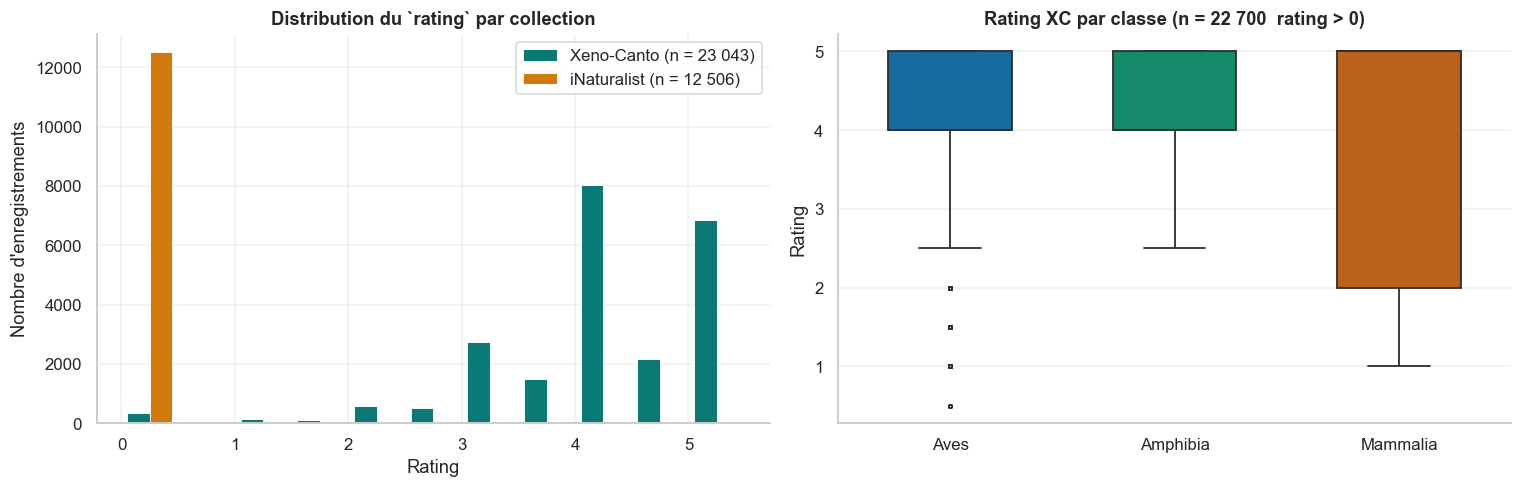

XC : 23 043 enregistrements  dont 343 sans rating (1.5 %)
XC ratings > 0 : moyenne 4.07, médiane 4.0
iNat : 12 506 enregistrements  dont 0 avec un rating non nul


In [12]:
# 2.2 Distribution du rating de qualité.
# `rating` : valeurs de 1 à 5 sur Xeno-Canto, 0 = non noté (et toujours 0 sur iNaturalist).

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))

# Histogramme empilé par collection
ax = axes[0]
bins = np.arange(0, 5.6, 0.5)
xc_ratings   = train_df.loc[train_df['collection'] == 'XC',   'rating']
inat_ratings = train_df.loc[train_df['collection'] == 'iNat', 'rating']
ax.hist([xc_ratings, inat_ratings], bins=bins,
        label=[f'Xeno-Canto (n = {len(xc_ratings):,})'.replace(',', ' '),
               f'iNaturalist (n = {len(inat_ratings):,})'.replace(',', ' ')],
        color=['#0B7A75', '#D17B0F'],
        edgecolor='white', linewidth=0.6, stacked=False)
ax.set_xlabel("Rating")
ax.set_ylabel("Nombre d'enregistrements")
ax.set_title("Distribution du `rating` par collection")
ax.legend(loc='upper right', frameon=True)
sns.despine(ax=ax)

# Boxplot par classe, XC seulement, rating > 0
ax = axes[1]
xc_rated = train_df[(train_df['collection'] == 'XC') & (train_df['rating'] > 0)]
order = [c for c in PALETTE_CLASSES if c in xc_rated['class_name'].unique()]
sns.boxplot(x='class_name', y='rating', hue='class_name', data=xc_rated,
            order=order, palette={c: PALETTE_CLASSES[c] for c in order},
            ax=ax, width=0.55, linewidth=1.2, fliersize=2, legend=False)
ax.set_xlabel("")
ax.set_ylabel("Rating")
ax.set_title(f"Rating XC par classe (n = {len(xc_rated):,}, rating > 0)".replace(',', ' '))
sns.despine(ax=ax)

plt.tight_layout()
plt.show()

# Stats résumées
print(f"XC : {len(xc_ratings):,} enregistrements, dont {(xc_ratings == 0).sum():,} sans rating "
      f"({(xc_ratings == 0).mean() * 100:.1f} %)".replace(',', ' '))
print(f"XC ratings > 0 : moyenne {xc_ratings[xc_ratings > 0].mean():.2f}, médiane {xc_ratings[xc_ratings > 0].median():.1f}")
print(f"iNat : {len(inat_ratings):,} enregistrements, dont {(inat_ratings > 0).sum()} avec un rating non nul"
      .replace(',', ' '))

Enregistrements avec au moins un type renseigné : 22 574 (63.5 %)
Enregistrements sans type ([])                    : 12 975
Vocabulaire distinct de types                     : 591


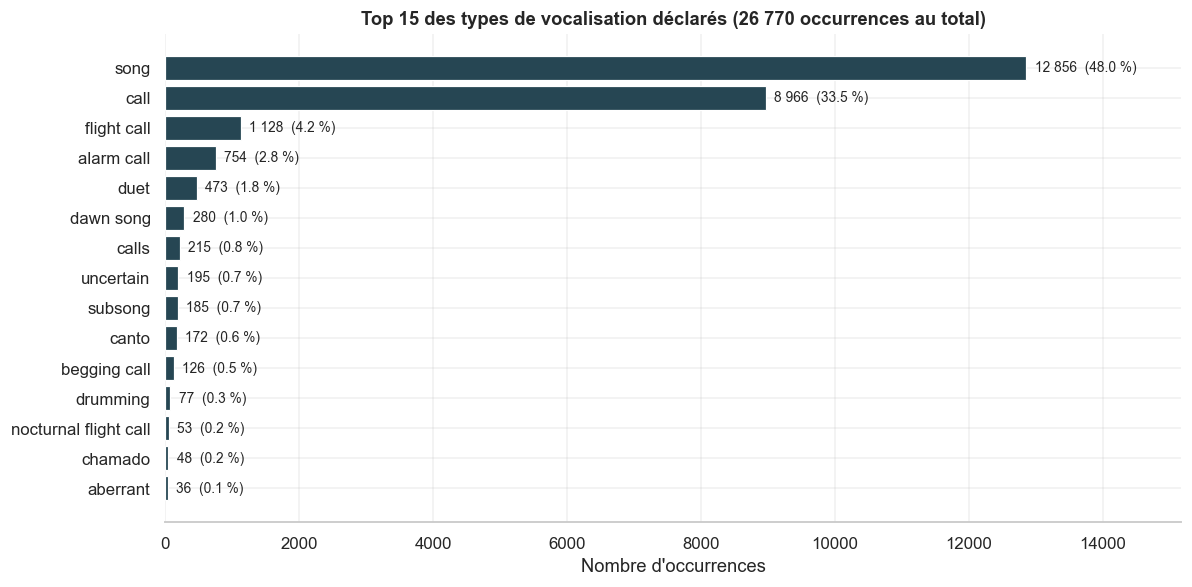

In [13]:
# 2.3 Types de vocalisation déclarés (colonne `type`).
# Le champ est une string-liste à parser ("[]", "['song']", "['call', ' song']").

import ast

def parse_list_str(s):
    """Convertit une chaîne représentant une liste Python en liste de strings (avec strip)."""
    if not isinstance(s, str):
        return []
    try:
        v = ast.literal_eval(s)
        return [x.strip() for x in v] if isinstance(v, list) else []
    except Exception:
        return []

train_df['type_list'] = train_df['type'].apply(parse_list_str)
type_counts = train_df.explode('type_list')['type_list'].dropna().value_counts()

has_type = train_df['type_list'].apply(len) > 0
print(f"Enregistrements avec au moins un type renseigné : {has_type.sum():,} "
      f"({has_type.mean() * 100:.1f} %)".replace(',', ' '))
print(f"Enregistrements sans type ([])                    : {(~has_type).sum():,}"
      .replace(',', ' '))
print(f"Vocabulaire distinct de types                     : {type_counts.size}")

top_types = type_counts.head(15)

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.barh(top_types.index[::-1], top_types.values[::-1],
        color='#264653', edgecolor='white', linewidth=0.8)
total_type_occurrences = type_counts.sum()
for i, v in enumerate(top_types.values[::-1]):
    pct = v / total_type_occurrences * 100
    ax.text(v + top_types.max() * 0.01, i, f'{v:,}  ({pct:.1f} %)'.replace(',', ' '),
            va='center', fontsize=9)
ax.set_title(f"Top 15 des types de vocalisation déclarés ({total_type_occurrences:,} occurrences au total)"
             .replace(',', ' '))
ax.set_xlabel("Nombre d'occurrences")
ax.set_xlim(0, top_types.max() * 1.18)
sns.despine(left=True)
plt.tight_layout()
plt.show()

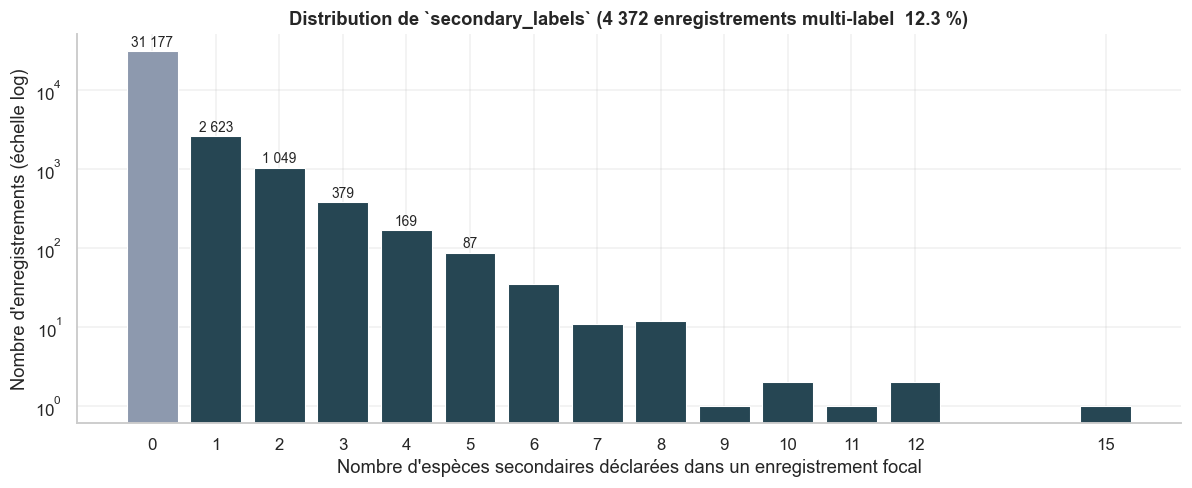

Enregistrements avec au moins une espèce secondaire : 4 372 (12.3 %)
Maximum d'espèces secondaires dans un seul fichier  : 15
Nombre moyen de labels par enregistrement multi      : 1.70


In [14]:
# 2.4 Espèces secondaires dans les enregistrements focaux.
# Mesure du multi-label déjà présent dans le focal (recordist a marqué d'autres espèces audibles).

train_df['secondary_list'] = train_df['secondary_labels'].apply(parse_list_str)
train_df['n_secondary']    = train_df['secondary_list'].apply(len)

sec_dist = train_df['n_secondary'].value_counts().sort_index()
n_multi = (train_df['n_secondary'] > 0).sum()

fig, ax = plt.subplots(figsize=(11, 4.6))
colors_bar = ['#8D99AE' if k == 0 else '#264653' for k in sec_dist.index]
bars = ax.bar(sec_dist.index, sec_dist.values, color=colors_bar,
              edgecolor='white', linewidth=0.7)
for bar, val, k in zip(bars, sec_dist.values, sec_dist.index):
    label = f'{val:,}'.replace(',', ' ')
    if val > 50:
        ax.text(bar.get_x() + bar.get_width() / 2, val * 1.15, label,
                ha='center', fontsize=9)
ax.set_yscale('log')
ax.set_xlabel("Nombre d'espèces secondaires déclarées dans un enregistrement focal")
ax.set_ylabel("Nombre d'enregistrements (échelle log)")
ax.set_title(f"Distribution de `secondary_labels` ({n_multi:,} enregistrements multi-label, "
             f"{n_multi / len(train_df) * 100:.1f} %)".replace(',', ' '))
ax.set_xticks(sec_dist.index)
sns.despine()
plt.tight_layout()
plt.show()

print(f"Enregistrements avec au moins une espèce secondaire : {n_multi:,} "
      f"({n_multi / len(train_df) * 100:.1f} %)".replace(',', ' '))
print(f"Maximum d'espèces secondaires dans un seul fichier  : {train_df['n_secondary'].max()}")
print(f"Nombre moyen de labels par enregistrement multi      : "
      f"{train_df.loc[train_df['n_secondary'] > 0, 'n_secondary'].mean():.2f}")

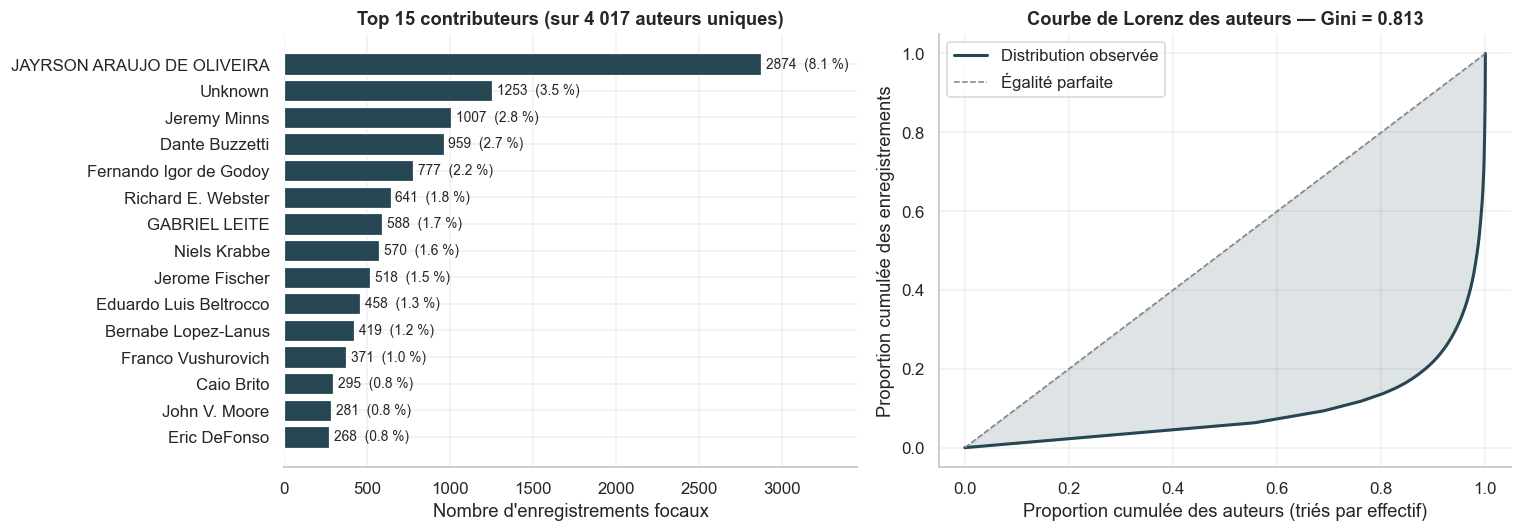

Auteurs uniques                                : 4 017
Coefficient de Gini (concentration auteurs)     : 0.813
Top contributeur (JAYRSON ARAUJO DE OLIVEIRA)    : 2874 enr. (8.1 %)
Top 10 % des auteurs (402)            : 78.2 % des enregistrements
Top 100 auteurs                                : 57.6 % des enregistrements


In [15]:
# 2.5 Concentration des contributions par auteur.
# Top contributeurs + courbe de Lorenz + Gini sur les auteurs.

author_counts = train_df['author'].value_counts()
g_authors     = gini(author_counts.values)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top 15 contributeurs
ax = axes[0]
top_authors = author_counts.head(15)
ax.barh(top_authors.index[::-1], top_authors.values[::-1],
        color='#264653', edgecolor='white', linewidth=0.8)
for i, v in enumerate(top_authors.values[::-1]):
    pct = v / len(train_df) * 100
    ax.text(v + top_authors.max() * 0.01, i, f'{v}  ({pct:.1f} %)',
            va='center', fontsize=9)
ax.set_title(f"Top 15 contributeurs (sur {len(author_counts):,} auteurs uniques)".replace(',', ' '))
ax.set_xlabel("Nombre d'enregistrements focaux")
ax.set_xlim(0, top_authors.max() * 1.2)
sns.despine(left=True, ax=ax)

# Lorenz
ax = axes[1]
sorted_a    = np.sort(author_counts.values)
cum_share_a = np.concatenate([[0], np.cumsum(sorted_a) / sorted_a.sum()])
cum_pop_a   = np.concatenate([[0], np.arange(1, len(sorted_a) + 1) / len(sorted_a)])
ax.plot(cum_pop_a, cum_share_a, color='#264653', linewidth=2, label='Distribution observée')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Égalité parfaite')
ax.fill_between(cum_pop_a, cum_share_a, cum_pop_a, color='#264653', alpha=0.15)
ax.set_xlabel("Proportion cumulée des auteurs (triés par effectif)")
ax.set_ylabel("Proportion cumulée des enregistrements")
ax.set_title(f"Courbe de Lorenz des auteurs - Gini = {g_authors:.3f}")
ax.legend(loc='upper left', frameon=True)
sns.despine(ax=ax)

plt.tight_layout()
plt.show()

n_authors      = len(author_counts)
top_10pct_n    = max(1, int(round(n_authors * 0.10)))
share_top_10p  = author_counts.sort_values(ascending=False).iloc[:top_10pct_n].sum() / len(train_df)
share_top_1    = author_counts.iloc[0] / len(train_df)
share_top_100  = author_counts.sort_values(ascending=False).iloc[:100].sum() / len(train_df)
print(f"Auteurs uniques                                : {n_authors:,}".replace(',', ' '))
print(f"Coefficient de Gini (concentration auteurs)     : {g_authors:.3f}")
print(f"Top contributeur ({author_counts.index[0]})    : {author_counts.iloc[0]} enr. "
      f"({share_top_1 * 100:.1f} %)")
print(f"Top 10 % des auteurs ({top_10pct_n})            : {share_top_10p * 100:.1f} % des enregistrements")
print(f"Top 100 auteurs                                : {share_top_100 * 100:.1f} % des enregistrements")

In [16]:
# 2.6 Licences. Distribution simple, pour information.
license_counts = train_df['license'].value_counts()
license_pct    = (license_counts / len(train_df) * 100).round(2)
print("Distribution des licences :")
print(pd.DataFrame({'count': license_counts, '%': license_pct}).to_string())

Distribution des licences :
             count      %
license                  
by-nc-sa     22843  64.26
cc-by-nc      9651  27.15
cc-by         2202   6.19
cc0            290   0.82
cc-by-nc-sa    249   0.70
by-sa          200   0.56
cc-by-sa       114   0.32


### Observation Section 2

**Déséquilibre par espèce**
- Gini 0,490 sur les 206 espèces avec focal.
- Top plafonné à 499 enregistrements (cap appliqué en amont, downsampling inutile).
- 14 espèces sous 5 enregistrements, 4 espèces avec un seul fichier.
- Les 4 espèces à 1 fichier ne peuvent pas entrer dans un `StratifiedGroupKFold` à 5 folds : à exclure de la validation croisée ou à traiter en leave-one-out dédié.

**Rating de qualité**
- XC : 98,5 % notés, moyenne 4,07/5.
- iNat : 0 % notés par construction.
- Un filtrage par rating supprimerait l'ensemble d'iNat, donc quasiment toutes les classes hors Aves. À proscrire comme filtre.
- Utilisation envisageable comme `sample_weight` LightGBM sur XC uniquement.

**Types de vocalisation**
- 63,5 % renseignés, 591 types distincts, vocabulaire très bruité.
- Variable indisponible sur le test, donc pas une feature directe.
- Si exploitée, canoniser en 5 à 7 catégories canoniques (song, call, alarm, flight, duet, dawn, unknown).

**Espèces secondaires dans le focal**
- 12,3 % des fichiers focaux sont déjà multi-label (4 372 fichiers, moyenne 1,7 espèce secondaire).
- Entraînement à conduire en multi-label (primary ∪ secondary), sinon le modèle apprend explicitement à dire « non » sur des espèces effectivement présentes.
- Maximum à 15 espèces secondaires sur un seul fichier : probable soundscape mal classé, à investiguer ponctuellement.

**Concentration par auteur**
- 4 017 auteurs, Gini 0,813. Top contributeur = 8,1 %. Top 100 = 57,6 %.
- Forte corrélation acoustique intra-auteur (microphone, environnement).
- Risque de fuite inter-fold si le grouping de validation ne porte que sur `filename`. À tester en comparatif un grouping par auteur, et à documenter dans le rapport au titre de la rigueur de validation.

**Licences**
- Toutes Creative Commons, dominante `by-nc-sa` (64,3 %).
- Aucun impact modélisation.

## Section 3. Géographie et représentativité spatiale

Le test du benchmark se déroule sur des soundscapes enregistrés dans le Pantanal brésilien (latitude entre -16,5 et -21,6, longitude entre -55,9 et -57,6, d'après `recording_location.txt`). L'objectif de la section est de déterminer dans quelle mesure les enregistrements focaux d'entraînement ont été captés à proximité de cette zone cible, ou s'ils proviennent au contraire d'autres régions d'Amérique du Sud, ce qui constituerait un risque de *domain shift* géographique.

Quatre questions sont traitées : qualité des coordonnées de `train.csv`, localisation des fichiers focaux sur fond de carte, quantification de la distance au Pantanal et de la part de fichiers effectivement dans la zone, et enfin recensement des sites soundscape (`Sxx`) couverts par les fichiers annotés versus ceux disponibles uniquement en train non annoté.

In [17]:
# 3.1 Vérification de la qualité des coordonnées géographiques.

# Définition de la zone Pantanal (d'après recording_location.txt).
PANTANAL_LAT = (-21.6, -16.5)   # (min, max)
PANTANAL_LON = (-57.6, -55.9)   # (min, max)
PANTANAL_CENTROID = (
    (PANTANAL_LAT[0] + PANTANAL_LAT[1]) / 2,
    (PANTANAL_LON[0] + PANTANAL_LON[1]) / 2,
)

lat_nan      = train_df['latitude'].isna().sum()
lon_nan      = train_df['longitude'].isna().sum()
lat_lon_zero = ((train_df['latitude'] == 0) & (train_df['longitude'] == 0)).sum()
lat_aberr    = ((train_df['latitude'] < -90) | (train_df['latitude'] > 90)).sum()
lon_aberr    = ((train_df['longitude'] < -180) | (train_df['longitude'] > 180)).sum()

print(f"Latitudes manquantes  : {lat_nan}")
print(f"Longitudes manquantes : {lon_nan}")
print(f"Couples (0, 0)        : {lat_lon_zero}")
print(f"Latitudes aberrantes  (hors [-90, 90])  : {lat_aberr}")
print(f"Longitudes aberrantes (hors [-180, 180]) : {lon_aberr}")
print()
print(f"Latitude  : min {train_df['latitude'].min():.2f}, max {train_df['latitude'].max():.2f}")
print(f"Longitude : min {train_df['longitude'].min():.2f}, max {train_df['longitude'].max():.2f}")
print()

# Distance haversine de chaque point au centroïde du Pantanal.
def haversine_km(lat1, lon1, lat2, lon2):
    """Distance en kilomètres entre deux points (formule haversine)."""
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))

train_df['dist_pantanal_km'] = haversine_km(
    train_df['latitude'].values, train_df['longitude'].values,
    PANTANAL_CENTROID[0], PANTANAL_CENTROID[1]
)

# Flag dans/hors zone Pantanal (boîte englobante stricte).
train_df['in_pantanal'] = (
    train_df['latitude'].between(PANTANAL_LAT[0], PANTANAL_LAT[1]) &
    train_df['longitude'].between(PANTANAL_LON[0], PANTANAL_LON[1])
)
print(f"Zone Pantanal définie : lat ∈ {PANTANAL_LAT}, lon ∈ {PANTANAL_LON}")
print(f"Centroïde retenu pour les distances : {PANTANAL_CENTROID}")

Latitudes manquantes  : 0
Longitudes manquantes : 0
Couples (0, 0)        : 0
Latitudes aberrantes  (hors [-90, 90])  : 0
Longitudes aberrantes (hors [-180, 180]) : 0

Latitude  : min -54.86, max 69.58
Longitude : min -159.66, max 175.32

Zone Pantanal définie : lat ∈ (-21.6, -16.5), lon ∈ (-57.6, -55.9)
Centroïde retenu pour les distances : (-19.05, -56.75)


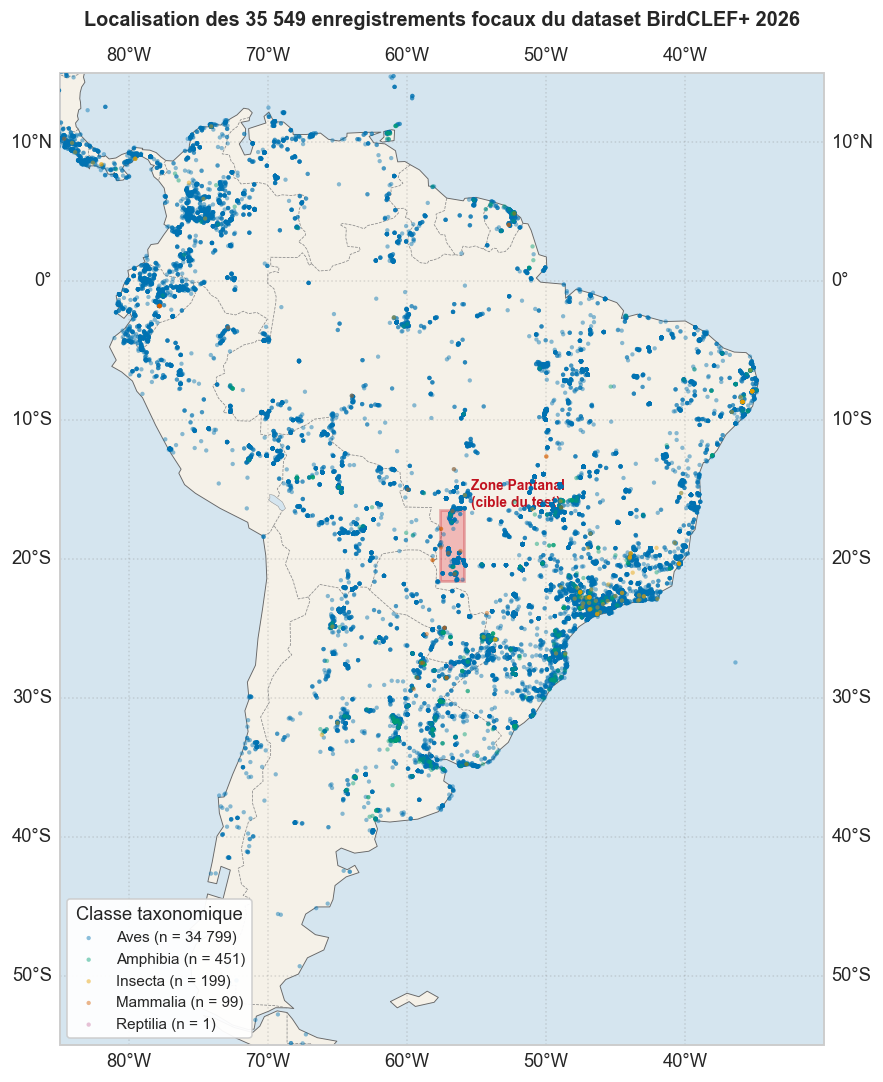

In [18]:
# 3.2 Carte des enregistrements focaux sur fond de carte d'Amérique du Sud.
# La zone Pantanal est mise en surbrillance, les points sont colorés par classe taxonomique.

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.patches import Rectangle

fig = plt.figure(figsize=(12, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

# Étendue centrée sur l'Amérique du Sud, avec marge pour voir le Pantanal au centre.
ax.set_extent([-85, -30, -55, 15], crs=ccrs.PlateCarree())

# Fond de carte : terre, océan, côtes, frontières des pays.
ax.add_feature(cfeature.LAND,      facecolor='#F5F1E8')
ax.add_feature(cfeature.OCEAN,     facecolor='#D5E5EF')
ax.add_feature(cfeature.COASTLINE, edgecolor='#666',  linewidth=0.6)
ax.add_feature(cfeature.BORDERS,   edgecolor='#888',  linewidth=0.5, linestyle='--')
ax.add_feature(cfeature.LAKES,     facecolor='#D5E5EF', edgecolor='#888', linewidth=0.3)

# Zone Pantanal en rectangle rouge translucide.
pantanal_rect = Rectangle(
    (PANTANAL_LON[0], PANTANAL_LAT[0]),
    PANTANAL_LON[1] - PANTANAL_LON[0],
    PANTANAL_LAT[1] - PANTANAL_LAT[0],
    linewidth=1.8, edgecolor='#C1121F',
    facecolor='#E63946', alpha=0.30,
    transform=ccrs.PlateCarree(), zorder=3,
)
ax.add_patch(pantanal_rect)
ax.text(PANTANAL_LON[1] + 0.5, PANTANAL_LAT[1] + 0.3, 'Zone Pantanal\n(cible du test)',
        fontsize=9, color='#C1121F', fontweight='bold',
        transform=ccrs.PlateCarree(), zorder=4)

# Scatter des enregistrements focaux, couleur par classe taxonomique.
for cls in ['Aves', 'Amphibia', 'Insecta', 'Mammalia', 'Reptilia']:
    sub = train_df[train_df['class_name'] == cls]
    ax.scatter(sub['longitude'], sub['latitude'],
               c=PALETTE_CLASSES[cls], s=8, alpha=0.45, edgecolor='none',
               label=f'{cls} (n = {len(sub):,})'.replace(',', ' '),
               transform=ccrs.PlateCarree(), zorder=4)

ax.legend(loc='lower left', fontsize=10, framealpha=0.95, title='Classe taxonomique')
ax.gridlines(draw_labels=True, alpha=0.25, linestyle=':', color='gray')
ax.set_title("Localisation des 35 549 enregistrements focaux du dataset BirdCLEF+ 2026",
             fontsize=13, pad=14, fontweight='bold')
plt.tight_layout()
plt.show()

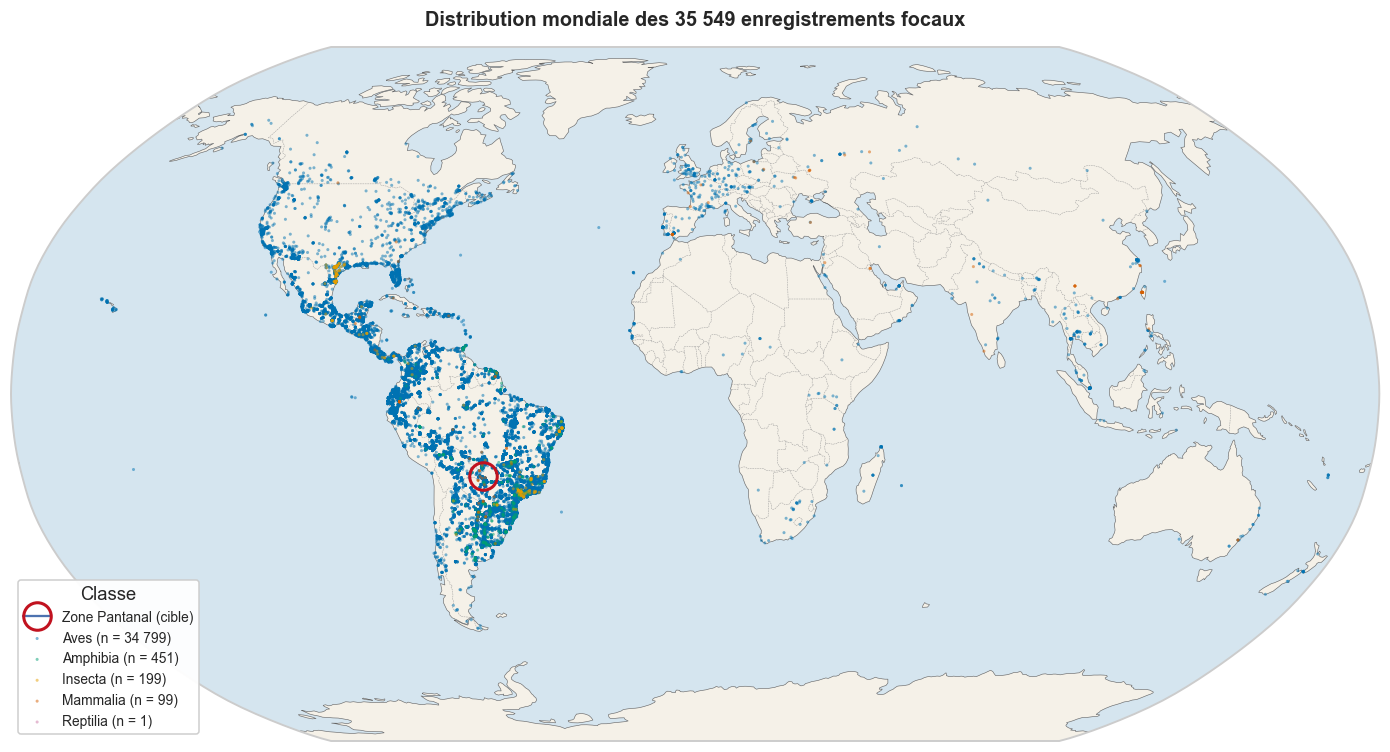

Répartition approximative par grande région :
  Amérique du Sud       29 465  (82.9 %)
  Amérique du Nord       4 817  (13.6 %)
  Autre / océan            536  (1.5 %)
  Europe                   343  (1.0 %)
  Asie                     247  (0.7 %)
  Afrique                  107  (0.3 %)
  Océanie                   34  (0.1 %)


In [19]:
# 3.2 bis. Carte mondiale des enregistrements focaux.
# Complément de la carte précédente : montre que le dataset déborde largement de l'Amérique du Sud.

fig = plt.figure(figsize=(14, 7))
ax = plt.axes(projection=ccrs.Robinson())
ax.set_global()

ax.add_feature(cfeature.LAND,      facecolor='#F5F1E8')
ax.add_feature(cfeature.OCEAN,     facecolor='#D5E5EF')
ax.add_feature(cfeature.COASTLINE, edgecolor='#666',  linewidth=0.4)
ax.add_feature(cfeature.BORDERS,   edgecolor='#999',  linewidth=0.3, linestyle='--')

# Zone Pantanal en surbrillance (petit rectangle rouge, peu visible à cette échelle
# mais marqué d'un cercle pour le retrouver).
ax.plot(PANTANAL_CENTROID[1], PANTANAL_CENTROID[0],
        marker='o', markerfacecolor='none', markeredgecolor='#C1121F',
        markersize=18, markeredgewidth=2,
        transform=ccrs.PlateCarree(), zorder=5, label='Zone Pantanal (cible)')

# Scatter des focaux par classe.
for cls in ['Aves', 'Amphibia', 'Insecta', 'Mammalia', 'Reptilia']:
    sub = train_df[train_df['class_name'] == cls]
    ax.scatter(sub['longitude'], sub['latitude'],
               c=PALETTE_CLASSES[cls], s=4, alpha=0.5, edgecolor='none',
               label=f'{cls} (n = {len(sub):,})'.replace(',', ' '),
               transform=ccrs.PlateCarree(), zorder=4)

ax.legend(loc='lower left', fontsize=9, framealpha=0.95, title='Classe')
ax.set_title("Distribution mondiale des 35 549 enregistrements focaux",
             fontsize=13, pad=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Comptage par continent grossier (basé sur des bounding boxes simples).
def rough_region(lat, lon):
    if -55 <= lat <= 15 and -85 <= lon <= -30:
        return 'Amérique du Sud'
    if 15 < lat <= 85 and -170 <= lon <= -50:
        return 'Amérique du Nord'
    if 35 <= lat <= 80 and -15 <= lon <= 60:
        return 'Europe'
    if -40 <= lat <= 40 and -20 <= lon <= 55:
        return 'Afrique'
    if -10 <= lat <= 80 and 60 <= lon <= 180:
        return 'Asie'
    if -50 <= lat <= -10 and 110 <= lon <= 180:
        return 'Océanie'
    return 'Autre / océan'

train_df['region_approx'] = [rough_region(la, lo) for la, lo in 
                              zip(train_df['latitude'], train_df['longitude'])]
region_counts = train_df['region_approx'].value_counts()
print("Répartition approximative par grande région :")
for region, count in region_counts.items():
    print(f"  {region:<20}  {count:>6,}  ({count / len(train_df) * 100:.1f} %)".replace(',', ' '))

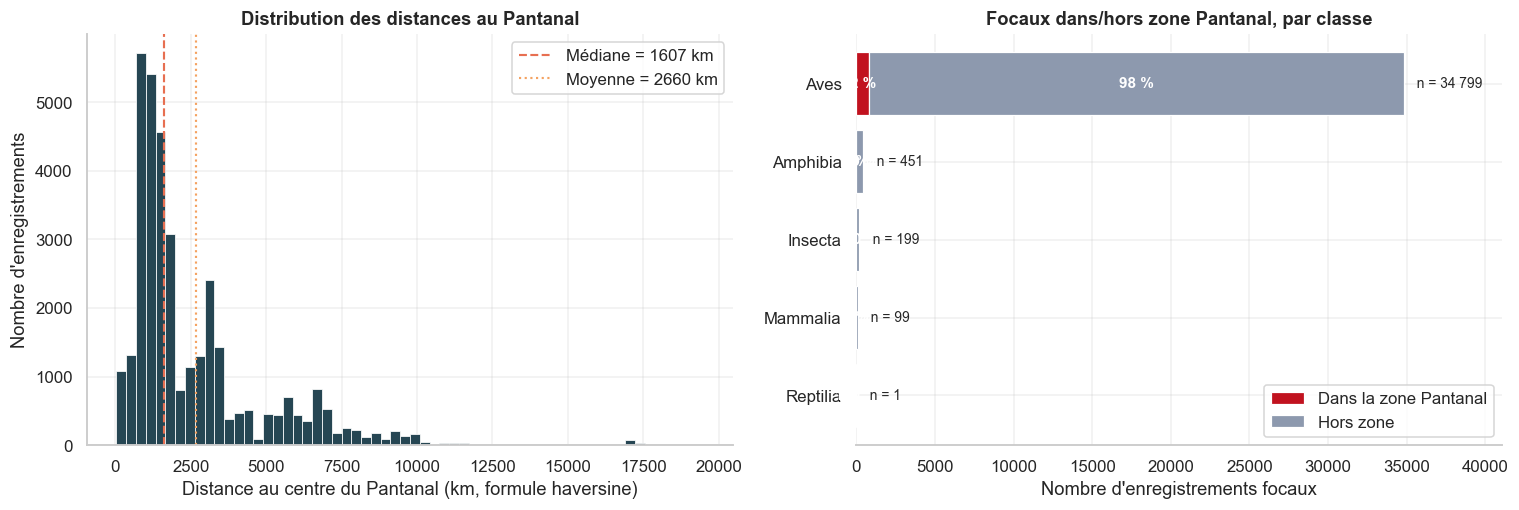

Focaux dans la zone Pantanal : 847 (2.4 %)
Focaux hors zone             : 34 702 (97.6 %)
Distance médiane au centre du Pantanal : 1607 km
Distance moyenne au centre du Pantanal : 2660 km
Distance max observée                  : 19496 km


In [20]:
# 3.3 Distance au Pantanal et proportion dans/hors zone par classe.

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

# Histogramme des distances (échelle log sur l'axe x pour gérer l'amplitude).
ax = axes[0]
ax.hist(train_df['dist_pantanal_km'], bins=60,
        color='#264653', edgecolor='white', linewidth=0.5)
median_dist = train_df['dist_pantanal_km'].median()
mean_dist   = train_df['dist_pantanal_km'].mean()
ax.axvline(median_dist, color='#E76F51', linestyle='--', linewidth=1.4,
           label=f'Médiane = {median_dist:.0f} km')
ax.axvline(mean_dist, color='#F4A261', linestyle=':', linewidth=1.4,
           label=f'Moyenne = {mean_dist:.0f} km')
ax.set_xlabel("Distance au centre du Pantanal (km, formule haversine)")
ax.set_ylabel("Nombre d'enregistrements")
ax.set_title("Distribution des distances au Pantanal")
ax.legend(loc='upper right', frameon=True)
sns.despine(ax=ax)

# Stacked bar dans/hors zone par classe.
ax = axes[1]
in_out = (
    train_df.groupby(['class_name', 'in_pantanal'])
    .size()
    .unstack(fill_value=0)
)
in_out.columns = [bool(c) for c in in_out.columns]
for c in (True, False):
    if c not in in_out.columns:
        in_out[c] = 0
in_out['total'] = in_out[True] + in_out[False]
in_out = in_out.sort_values('total', ascending=True)
totals = in_out['total']
dans   = in_out[True].values
hors   = in_out[False].values

ax.barh(in_out.index, dans, color='#C1121F', edgecolor='white', linewidth=0.8,
        label='Dans la zone Pantanal')
ax.barh(in_out.index, hors, left=dans, color='#8D99AE', edgecolor='white', linewidth=0.8,
        label='Hors zone')

for i, (d, h, t) in enumerate(zip(dans, hors, totals.values)):
    if d > 0:
        ax.text(d / 2, i, f'{d / t * 100:.0f} %',
                ha='center', va='center', color='white', fontsize=10, fontweight='bold')
    if h > 0:
        ax.text(d + h / 2, i, f'{h / t * 100:.0f} %',
                ha='center', va='center', color='white', fontsize=10, fontweight='bold')
    ax.text(t + totals.max() * 0.01, i, f'  n = {t:,}'.replace(',', ' '),
            va='center', fontsize=9)

ax.set_xlim(0, totals.max() * 1.18)
ax.set_title("Focaux dans/hors zone Pantanal, par classe")
ax.set_xlabel("Nombre d'enregistrements focaux")
ax.legend(loc='lower right', frameon=True)
sns.despine(left=True, ax=ax)

plt.tight_layout()
plt.show()

n_in  = train_df['in_pantanal'].sum()
n_out = (~train_df['in_pantanal']).sum()
print(f"Focaux dans la zone Pantanal : {n_in:,} ({n_in / len(train_df) * 100:.1f} %)".replace(',', ' '))
print(f"Focaux hors zone             : {n_out:,} ({n_out / len(train_df) * 100:.1f} %)".replace(',', ' '))
print(f"Distance médiane au centre du Pantanal : {median_dist:.0f} km")
print(f"Distance moyenne au centre du Pantanal : {mean_dist:.0f} km")
print(f"Distance max observée                  : {train_df['dist_pantanal_km'].max():.0f} km")

In [21]:
# 3.4 Sites soundscape : annotés, non annotés, et test.
# Le code site est extrait du nom de fichier (motif "_S<digits>_").

import re
from pathlib import Path

def extract_site(filename: str) -> str | None:
    """Extrait le code site (ex. 'S08') d'un nom de fichier BC2026_*."""
    m = re.search(r'_S(\d+)_', filename)
    return f"S{m.group(1)}" if m else None

# Sites des soundscapes annotés (issus de soundscapes_df).
sites_annotated = sorted({extract_site(f) for f in soundscapes_df['filename'].unique()} - {None})

# Sites de l'ensemble des fichiers du dossier train_soundscapes (annotés + non annotés).
all_soundscape_files = sorted(p.name for p in Path(config.TRAIN_SOUNDSCAPES_DIR).glob('*.ogg'))
sites_all_train      = sorted({extract_site(f) for f in all_soundscape_files} - {None})

# Site test mentionné explicitement dans la documentation (exemple S05).
sites_test_known = ['S05']

# Compte de fichiers par site pour les annotés et pour l'ensemble du train.
files_per_site_annotated = {s: 0 for s in sites_all_train}
for f in soundscapes_df['filename'].unique():
    s = extract_site(f)
    if s:
        files_per_site_annotated[s] = files_per_site_annotated.get(s, 0) + 1

files_per_site_train_total = {s: 0 for s in sites_all_train}
for f in all_soundscape_files:
    s = extract_site(f)
    if s:
        files_per_site_train_total[s] = files_per_site_train_total.get(s, 0) + 1

print(f"Sites présents dans train_soundscapes/                : {sites_all_train}")
print(f"Sites parmi les fichiers annotés                       : {sites_annotated}")
print(f"Sites présents en train mais sans aucune annotation    : "
      f"{sorted(set(sites_all_train) - set(sites_annotated))}")
print(f"Site test mentionné explicitement dans la doc Kaggle   : {sites_test_known}")
print(f"Site test absent du train_soundscapes/                 : "
      f"{sorted(set(sites_test_known) - set(sites_all_train))}")
print()
print(f"Total fichiers train_soundscapes/ : {len(all_soundscape_files):,}".replace(',', ' '))
print(f"Total fichiers annotés (uniques)  : {soundscapes_df['filename'].nunique()}")
print()
print("Détail par site (fichiers annotés / total train) :")
for site in sites_all_train:
    annot = files_per_site_annotated.get(site, 0)
    total = files_per_site_train_total.get(site, 0)
    print(f"  {site} : {annot:>3} annoté(s) sur {total:>5} fichiers train")

Sites présents dans train_soundscapes/                : ['S01', 'S02', 'S03', 'S04', 'S05', 'S06', 'S07', 'S08', 'S09', 'S10', 'S11', 'S12', 'S13', 'S14', 'S15', 'S16', 'S17', 'S18', 'S19', 'S20', 'S21', 'S22', 'S23']
Sites parmi les fichiers annotés                       : ['S03', 'S08', 'S09', 'S13', 'S15', 'S18', 'S19', 'S22', 'S23']
Sites présents en train mais sans aucune annotation    : ['S01', 'S02', 'S04', 'S05', 'S06', 'S07', 'S10', 'S11', 'S12', 'S14', 'S16', 'S17', 'S20', 'S21']
Site test mentionné explicitement dans la doc Kaggle   : ['S05']
Site test absent du train_soundscapes/                 : []

Total fichiers train_soundscapes/ : 10 658
Total fichiers annotés (uniques)  : 66

Détail par site (fichiers annotés / total train) :
  S01 :   0 annoté(s) sur  2341 fichiers train
  S02 :   0 annoté(s) sur  2505 fichiers train
  S03 :   2 annoté(s) sur     5 fichiers train
  S04 :   0 annoté(s) sur    17 fichiers train
  S05 :   0 annoté(s) sur     9 fichiers train
  S06 :   

### Observation Section 3

**Qualité des coordonnées**
- Latitudes et longitudes complètes : 0 valeur manquante, 0 couple (0, 0), 0 valeur numériquement aberrante.
- Amplitude observée : latitude entre -54,86 et 69,58, longitude entre -159,66 et 175,32. Le dataset déborde largement de l'Amérique du Sud.

**Répartition géographique mondiale**
- 29 465 focaux (82,9 %) en Amérique du Sud.
- 4 817 focaux (13,6 %) en Amérique du Nord - proportion non négligeable.
- 343 en Europe, 247 en Asie, 107 en Afrique, 34 en Océanie, 536 hors continents identifiés (océans, zones frontières des bounding boxes utilisées).
- Près de 17 % du dataset focal vient donc d'environnements géographiquement très éloignés du Pantanal, et acoustiquement potentiellement très différents (dialectes locaux, espèces invasives ou cosmopolites).

**Domain shift géographique**
- Seulement 2,4 % des focaux (847 sur 35 549) sont situés dans la boîte englobante du Pantanal. 97,6 % sont hors zone.
- Distance médiane au centre du Pantanal : 1 607 km, moyenne 2 660 km, maximum 19 496 km.
- Conséquence directe : entraîné majoritairement sur des contextes acoustiques hors Pantanal, le modèle peut apprendre des dialectes ou variations régionales qui ne correspondent pas à celles du test.
- Trois leviers envisageables au moment de l'entraînement : pondération `sample_weight` proportionnelle à la proximité géographique, filtrage strict (par exemple ne garder que les enregistrements à moins de N km), ou aucune correction documentée comme limite assumée.

**Sites soundscape annotés versus site test**
- 23 sites distincts dans `train_soundscapes/` (S01 à S23), pour 10 658 fichiers au total.
- 9 sites disposent d'au moins une annotation expert (1 478 fenêtres 5 s, sur 66 fichiers distincts).
- Le site S05, mentionné dans la documentation Kaggle comme site test, est présent en train avec 9 fichiers non annotés. Utilisable pour caractériser son environnement acoustique mais pas pour l'entraînement supervisé direct.
- Concentration forte des annotations : S22 totalise 40 annotations sur 1 478. Si la validation croisée est groupée par `filename` seul, le modèle est évalué sur des fichiers d'un site déjà vu, ce qui produit un score CV optimiste par rapport au test qui inclut S05.

**Ressource pour pseudo-labeling**
- 10 592 fichiers `train_soundscapes/` non annotés, couvrant les 23 sites (S05 inclus).
- Couverture spatiale complète du domaine cible, à exploiter pour du pseudo-labeling si le temps le permet au jour 4.

## Section 4. Propriétés audio des fichiers focaux

Caractérisation technique des 35 549 fichiers audio focaux : durée, sample rate, nombre de canaux, taille de fichier (mesurés via les métadonnées d'en-tête sans décodage), et niveau sonore moyen RMS (mesuré sur l'ensemble du dataset par décodage audio complet parallélisé). L'objectif est de vérifier les hypothèses techniques annoncées par Kaggle (32 kHz, mono, OGG) et de quantifier la variabilité qui orientera le prétraitement (gestion des fichiers courts, stratégie de fenêtre pour les longs, normalisation du volume).

In [22]:
# 4.1 Métadonnées audio pour les 35 549 fichiers focaux.
# sf.info() lit uniquement l'en-tête du fichier (pas de décodage audio), donc rapide.
# Parallélisation avec joblib pour exploiter les 8 cœurs du M1.

import soundfile as sf
from joblib import Parallel, delayed
from tqdm.auto import tqdm

def get_meta(fname):
    """Renvoie un dict avec les métadonnées d'un fichier audio (sans décoder le signal)."""
    path = config.TRAIN_AUDIO_DIR / fname
    try:
        info = sf.info(str(path))
        return {
            'filename':    fname,
            'duration_s':  info.duration,
            'sample_rate': info.samplerate,
            'channels':    info.channels,
            'size_bytes':  path.stat().st_size,
        }
    except Exception as e:
        return {'filename': fname, 'error': str(e)}

all_files = train_df['filename'].tolist()
results = Parallel(n_jobs=-1, backend='threading')(
    delayed(get_meta)(f) for f in tqdm(all_files, desc='Métadonnées')
)
audio_meta_df = pd.DataFrame(results)
n_err = audio_meta_df['error'].notna().sum() if 'error' in audio_meta_df.columns else 0
if n_err:
    print(f"Erreurs : {n_err}")
    audio_meta_df = audio_meta_df[audio_meta_df.get('error').isna()].drop(columns='error', errors='ignore')

# Joindre la classe et la collection pour les analyses par groupe.
audio_meta_df = audio_meta_df.merge(
    train_df[['filename', 'class_name', 'collection', 'primary_label']],
    on='filename', how='left'
)
print(f"Fichiers analysés sans erreur : {len(audio_meta_df):,} / {len(train_df):,}".replace(',', ' '))
audio_meta_df.head()

Métadonnées:   0%|          | 0/35549 [00:00<?, ?it/s]

Fichiers analysés sans erreur : 35 549 / 35 549


,filename,duration_s,sample_rate,channels,size_bytes,class_name,collection,primary_label
0,1161364/iNat1216197.ogg,18.024,32000,1,169832,Insecta,iNat,1161364
1,1161364/iNat1114648.ogg,28.392,32000,1,254106,Insecta,iNat,1161364
2,1161364/iNat810195.ogg,80.016,32000,1,737744,Insecta,iNat,1161364
3,1161364/iNat818781.ogg,61.272,32000,1,576205,Insecta,iNat,1161364
4,1161364/iNat556514.ogg,71.064,32000,1,692070,Insecta,iNat,1161364


In [23]:
# 4.2 Sample rate, nombre de canaux, format (sur l'ensemble du dataset).
# Doc Kaggle : tous les fichiers à 32 kHz, mono, OGG. Vérification effective.

print("Sample rates observés :")
print(audio_meta_df['sample_rate'].value_counts().to_string())
print()
print("Nombre de canaux :")
print(audio_meta_df['channels'].value_counts().to_string())
print()
print("Formats (extension de fichier) :")
print(audio_meta_df['filename'].str.split('.').str[-1].value_counts().to_string())
print()
print("Taille des fichiers (Mo) :")
size_mb = audio_meta_df['size_bytes'] / 1e6
print(f"  min    : {size_mb.min():.3f}")
print(f"  médian : {size_mb.median():.3f}")
print(f"  moyen  : {size_mb.mean():.3f}")
print(f"  max    : {size_mb.max():.3f}")
print(f"  total  : {size_mb.sum() / 1024:.2f} Go")

Sample rates observés :
sample_rate
32000    35549

Nombre de canaux :
channels
1    35549

Formats (extension de fichier) :
filename
ogg    35549

Taille des fichiers (Mo) :
  min    : 0.004
  médian : 0.181
  moyen  : 0.303
  max    : 61.259
  total  : 10.50 Go


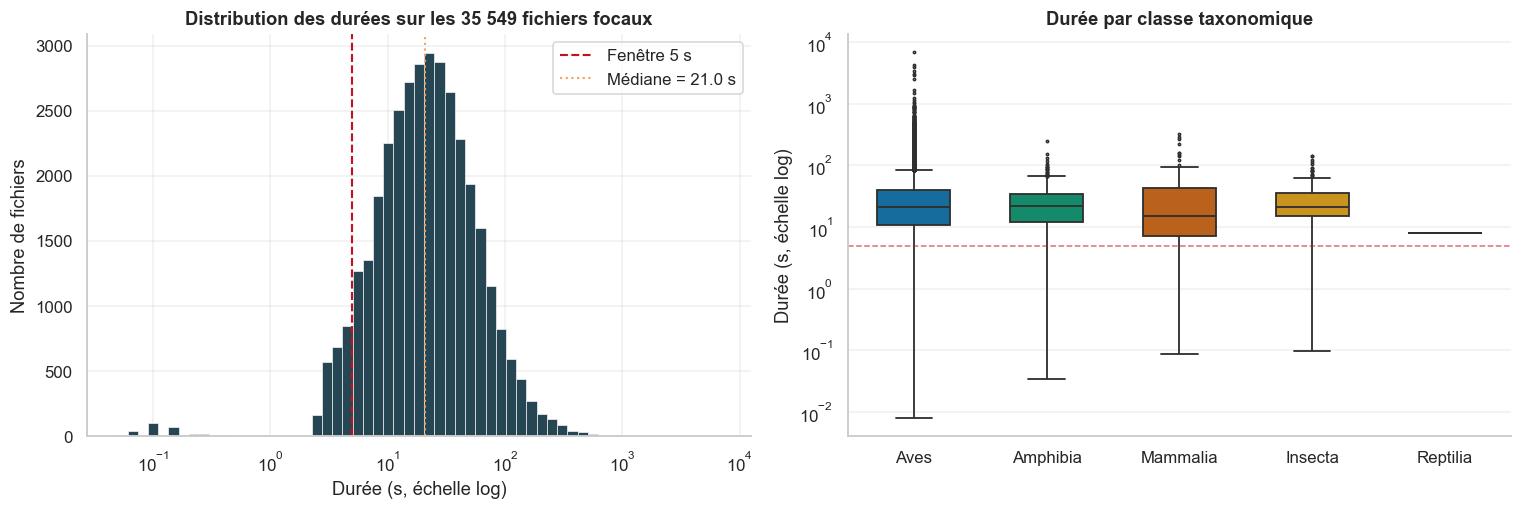

Durées sur 35 549 fichiers :
  min    : 0.01 s
  médiane: 21.0 s
  moyenne: 34.9 s
  max    : 6881.1 s

Fichiers < 5 s        : 2 601 (7.32 %)
Fichiers 5 à 30 s     : 20 338 (57.21 %)
Fichiers 30 à 60 s    : 7 782 (21.89 %)
Fichiers >= 60 s      : 4 828 (13.58 %)


In [24]:
# 4.3 Distribution des durées sur l'ensemble des 35 549 fichiers focaux.
# La fenêtre de prédiction est de 5 secondes : combien de fichiers sont plus courts ? Plus longs ?

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

# Histogramme global, échelle log x pour gérer l'amplitude (0,1 s à 900+ s).
ax = axes[0]
bins = np.logspace(np.log10(max(audio_meta_df['duration_s'].min(), 0.05)),
                   np.log10(audio_meta_df['duration_s'].max()), 60)
ax.hist(audio_meta_df['duration_s'], bins=bins, color='#264653', edgecolor='white', linewidth=0.4)
ax.set_xscale('log')
ax.axvline(5, color='#C1121F', linestyle='--', linewidth=1.4, label='Fenêtre 5 s')
median_dur = audio_meta_df['duration_s'].median()
ax.axvline(median_dur, color='#F4A261', linestyle=':', linewidth=1.4,
           label=f'Médiane = {median_dur:.1f} s')
ax.set_xlabel('Durée (s, échelle log)')
ax.set_ylabel("Nombre de fichiers")
ax.set_title(f"Distribution des durées sur les {len(audio_meta_df):,} fichiers focaux".replace(',', ' '))
ax.legend(loc='upper right', frameon=True)
sns.despine(ax=ax)

# Boxplot par classe (log y).
ax = axes[1]
order = [c for c in PALETTE_CLASSES if c in audio_meta_df['class_name'].unique()]
sns.boxplot(x='class_name', y='duration_s', hue='class_name', data=audio_meta_df,
            order=order, palette={c: PALETTE_CLASSES[c] for c in order},
            ax=ax, width=0.55, linewidth=1.2, fliersize=1.5, legend=False)
ax.set_yscale('log')
ax.set_xlabel('')
ax.set_ylabel('Durée (s, échelle log)')
ax.set_title('Durée par classe taxonomique')
ax.axhline(5, color='#C1121F', linestyle='--', linewidth=1.0, alpha=0.6)
sns.despine(ax=ax)

plt.tight_layout()
plt.show()

n_total = len(audio_meta_df)
print(f"Durées sur {n_total:,} fichiers :".replace(',', ' '))
print(f"  min    : {audio_meta_df['duration_s'].min():.2f} s")
print(f"  médiane: {audio_meta_df['duration_s'].median():.1f} s")
print(f"  moyenne: {audio_meta_df['duration_s'].mean():.1f} s")
print(f"  max    : {audio_meta_df['duration_s'].max():.1f} s")
print()
n_short = (audio_meta_df['duration_s'] < 5).sum()
n_mid   = ((audio_meta_df['duration_s'] >= 5) & (audio_meta_df['duration_s'] < 30)).sum()
n_long  = ((audio_meta_df['duration_s'] >= 30) & (audio_meta_df['duration_s'] < 60)).sum()
n_xlong = (audio_meta_df['duration_s'] >= 60).sum()
print(f"Fichiers < 5 s        : {n_short:,} ({n_short / n_total * 100:.2f} %)".replace(',', ' '))
print(f"Fichiers 5 à 30 s     : {n_mid:,} ({n_mid / n_total * 100:.2f} %)".replace(',', ' '))
print(f"Fichiers 30 à 60 s    : {n_long:,} ({n_long / n_total * 100:.2f} %)".replace(',', ' '))
print(f"Fichiers >= 60 s      : {n_xlong:,} ({n_xlong / n_total * 100:.2f} %)".replace(',', ' '))

RMS:   0%|          | 0/35549 [00:00<?, ?it/s]

Fichiers analysés sans erreur : 35 549 / 35 549



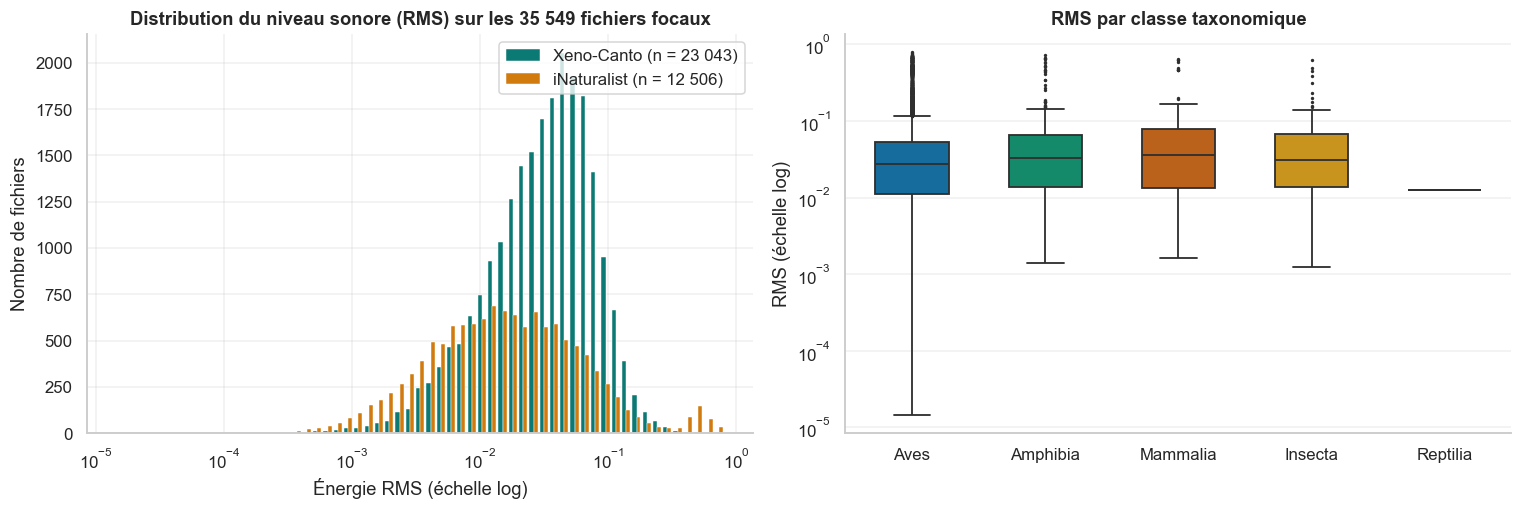

RMS global : min 0.0000, médiane 0.0273, moyenne 0.0430, max 0.7975
Ratio RMS max/min : 55376

RMS par collection :
            median    mean     std
collection                        
XC           0.034  0.0435  0.0388
iNat         0.015  0.0419  0.0908

RMS par classe :
            median    mean     std
class_name                        
Amphibia    0.0330  0.0622  0.1038
Aves        0.0272  0.0425  0.0609
Insecta     0.0305  0.0537  0.0776
Mammalia    0.0364  0.0873  0.1505
Reptilia    0.0125  0.0125     NaN

Fichiers avec RMS très faible (< 0.001, signal quasi-silencieux) :
  312 fichiers (0.88 %)


In [25]:
# 4.4 Niveau sonore moyen (RMS) sur l'ensemble des 35 549 fichiers focaux.
# Décodage audio complet parallélisé pour rester rapide (~5 min sur Mac M1).

def get_rms(fname):
    """Charge l'audio complet et calcule le RMS."""
    path = config.TRAIN_AUDIO_DIR / fname
    try:
        y, _ = librosa.load(str(path), sr=None, mono=True)
        return {'filename': fname, 'rms': float(np.sqrt(np.mean(y ** 2)))}
    except Exception as e:
        return {'filename': fname, 'rms': np.nan}

rms_results = Parallel(n_jobs=-1, backend='threading')(
    delayed(get_rms)(f) for f in tqdm(train_df['filename'].tolist(), desc='RMS')
)
rms_df = pd.DataFrame(rms_results).merge(
    train_df[['filename', 'class_name', 'collection', 'primary_label']],
    on='filename', how='left'
).dropna(subset=['rms'])

print(f"Fichiers analysés sans erreur : {len(rms_df):,} / {len(train_df):,}".replace(',', ' '))
print()

# Figures
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

ax = axes[0]
xc_rms   = rms_df.loc[rms_df['collection'] == 'XC',   'rms']
inat_rms = rms_df.loc[rms_df['collection'] == 'iNat', 'rms']
bins = np.logspace(np.log10(max(rms_df['rms'].min(), 1e-5)),
                   np.log10(rms_df['rms'].max()), 60)
ax.hist([xc_rms, inat_rms], bins=bins,
        label=[f'Xeno-Canto (n = {len(xc_rms):,})'.replace(',', ' '),
               f'iNaturalist (n = {len(inat_rms):,})'.replace(',', ' ')],
        color=['#0B7A75', '#D17B0F'], edgecolor='white', linewidth=0.3)
ax.set_xscale('log')
ax.set_xlabel("Énergie RMS (échelle log)")
ax.set_ylabel("Nombre de fichiers")
ax.set_title(f"Distribution du niveau sonore (RMS) sur les {len(rms_df):,} fichiers focaux".replace(',', ' '))
ax.legend(loc='upper right', frameon=True)
sns.despine(ax=ax)

ax = axes[1]
order_rms = [c for c in PALETTE_CLASSES if c in rms_df['class_name'].unique()]
sns.boxplot(x='class_name', y='rms', hue='class_name', data=rms_df,
            order=order_rms, palette={c: PALETTE_CLASSES[c] for c in order_rms},
            ax=ax, width=0.55, linewidth=1.2, fliersize=1.2, legend=False)
ax.set_yscale('log')
ax.set_xlabel('')
ax.set_ylabel('RMS (échelle log)')
ax.set_title('RMS par classe taxonomique')
sns.despine(ax=ax)

plt.tight_layout()
plt.show()

print(f"RMS global : min {rms_df['rms'].min():.4f}, médiane {rms_df['rms'].median():.4f}, "
      f"moyenne {rms_df['rms'].mean():.4f}, max {rms_df['rms'].max():.4f}")
print(f"Ratio RMS max/min : {rms_df['rms'].max() / max(rms_df['rms'].min(), 1e-9):.0f}")
print()
print("RMS par collection :")
print(rms_df.groupby('collection')['rms'].agg(['median', 'mean', 'std']).round(4).to_string())
print()
print("RMS par classe :")
print(rms_df.groupby('class_name')['rms'].agg(['median', 'mean', 'std']).round(4).to_string())
print()
print("Fichiers avec RMS très faible (< 0.001, signal quasi-silencieux) :")
n_silent = (rms_df['rms'] < 0.001).sum()
print(f"  {n_silent:,} fichiers ({n_silent / len(rms_df) * 100:.2f} %)".replace(',', ' '))

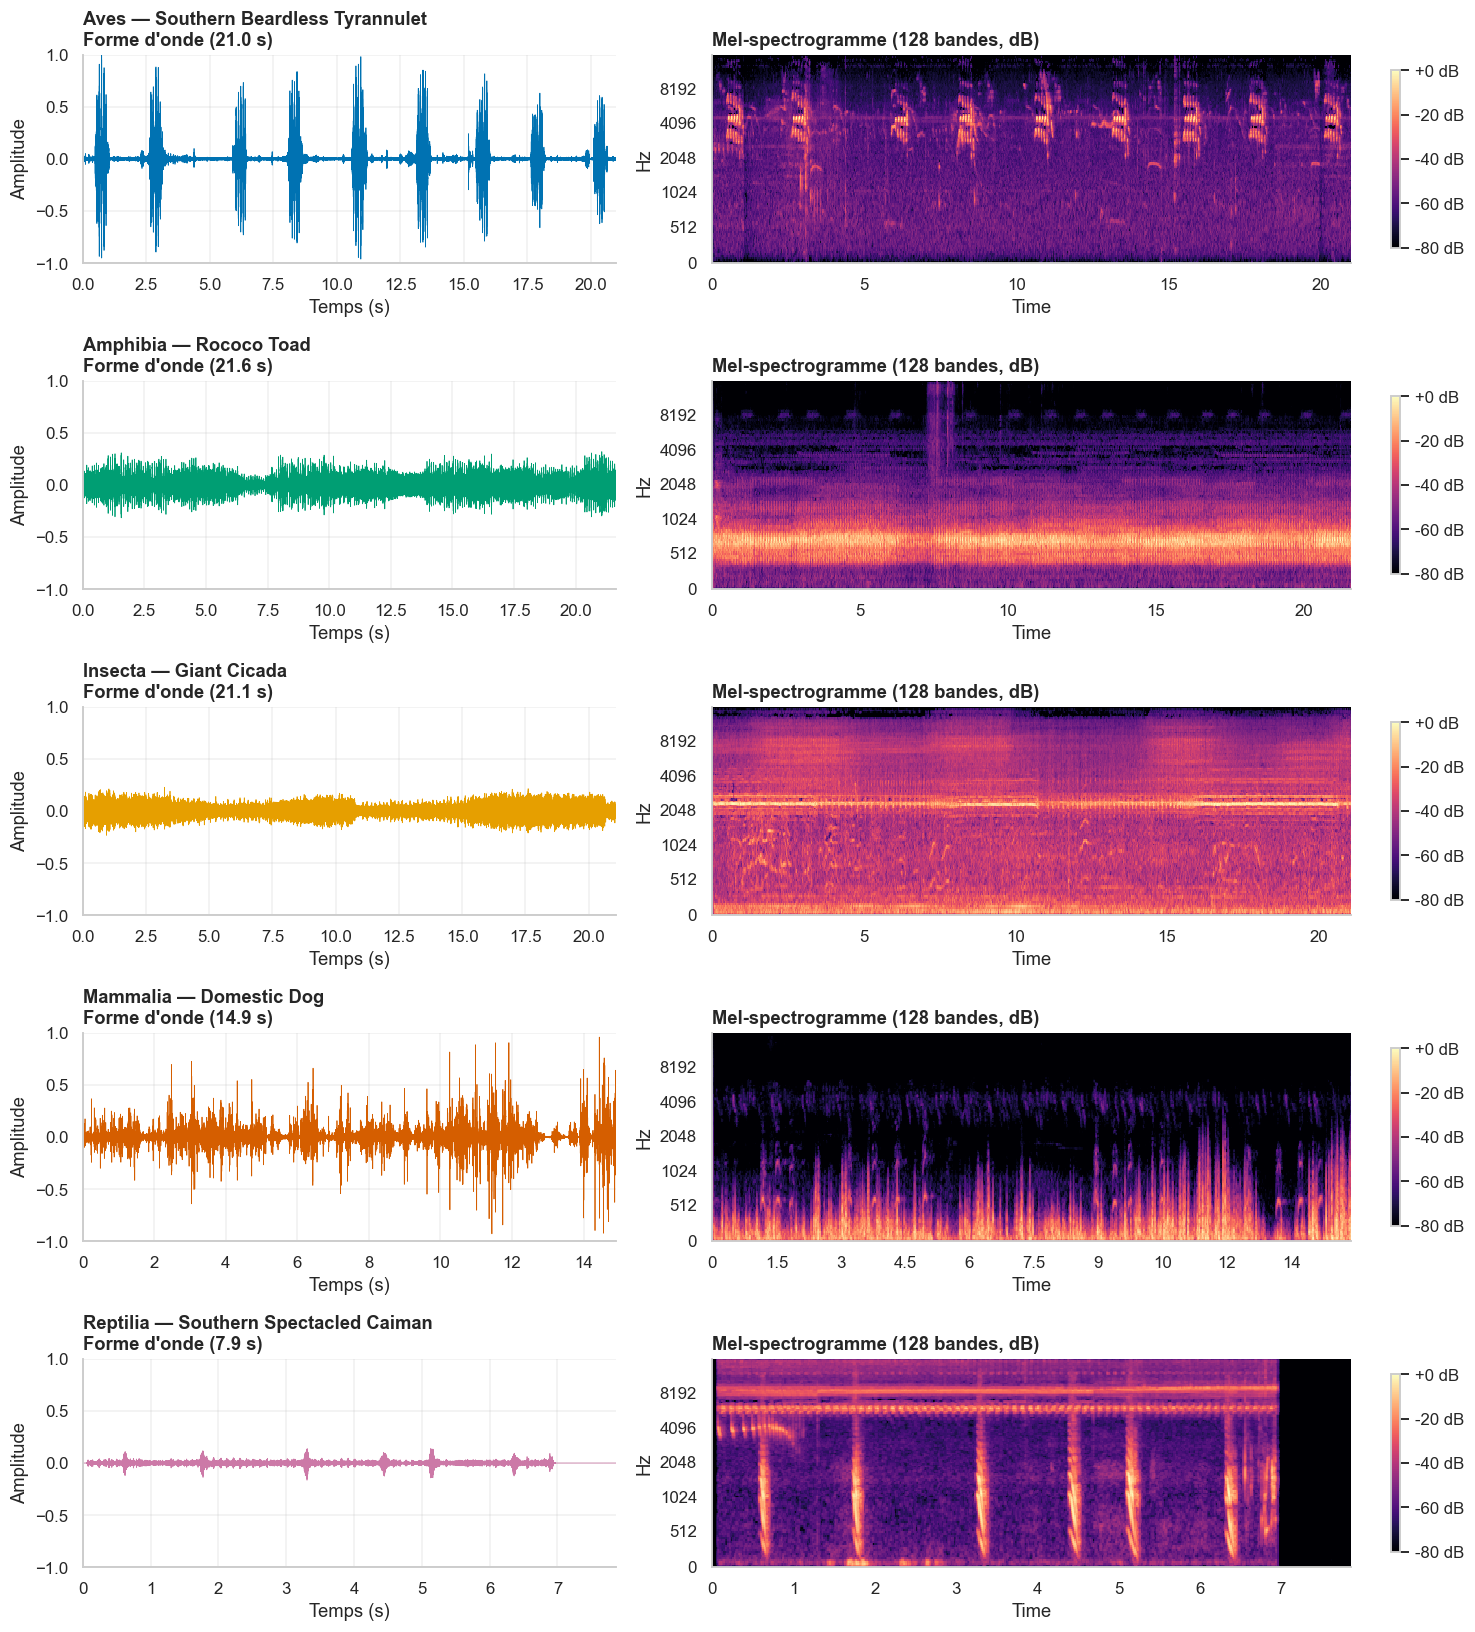

  Aves       : sobtyr1/XC451885.ogg  (21.0 s, 191 ko)
  Amphibia   : 67107/iNat1644752.ogg  (21.6 s, 163 ko)
  Insecta    : 244024/iNat271945.ogg  (21.1 s, 163 ko)
  Mammalia   : 47144/iNat1334302.ogg  (14.9 s, 113 ko)
  Reptilia   : 116570/iNat1460166.ogg  (7.9 s, 79 ko)


In [26]:
# 4.5 Visualisation : un fichier représentatif par classe taxonomique.
# Permet de confirmer visuellement la diversité acoustique entre groupes
# (chant d'oiseau, coassement d'amphibien, stridulation d'insecte, etc.).

import librosa.display

# Pour chaque classe, on choisit un fichier de durée proche de la médiane de sa classe.
# Cela évite les valeurs extrêmes (très courts ou très longs) qui ne sont pas représentatifs.
representatives = {}
for cls in ['Aves', 'Amphibia', 'Insecta', 'Mammalia', 'Reptilia']:
    sub = audio_meta_df[audio_meta_df['class_name'] == cls]
    if len(sub) == 0:
        continue
    median_dur = sub['duration_s'].median()
    idx = (sub['duration_s'] - median_dur).abs().idxmin()
    representatives[cls] = sub.loc[idx]

fig, axes = plt.subplots(len(representatives), 2, figsize=(14, 3 * len(representatives)),
                          gridspec_kw={'width_ratios': [1, 1.5]})
if len(representatives) == 1:
    axes = axes.reshape(1, 2)

for i, (cls, row) in enumerate(representatives.items()):
    fname = row['filename']
    path = config.TRAIN_AUDIO_DIR / fname
    y, sr = librosa.load(str(path), sr=None, mono=True)
    species_row = species_df[species_df['primary_label'] == row['primary_label']].iloc[0]
    species_name = species_row['common_name']
    duration = row['duration_s']

    # Waveform
    ax_w = axes[i, 0]
    times = np.arange(len(y)) / sr
    ax_w.plot(times, y, color=PALETTE_CLASSES[cls], linewidth=0.5)
    ax_w.set_xlim(0, duration)
    ax_w.set_ylim(-1, 1)
    ax_w.set_xlabel('Temps (s)')
    ax_w.set_ylabel('Amplitude')
    ax_w.set_title(f'{cls} - {species_name}\nForme d\'onde ({duration:.1f} s)', loc='left')
    sns.despine(ax=ax_w)

    # Mel-spectrogramme (échelle log fréquentielle proche de la perception)
    ax_s = axes[i, 1]
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=sr / 2)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    img = librosa.display.specshow(mel_db, sr=sr, x_axis='time', y_axis='mel',
                                    ax=ax_s, cmap='magma')
    ax_s.set_title(f'Mel-spectrogramme (128 bandes, dB)', loc='left')
    fig.colorbar(img, ax=ax_s, format='%+2.0f dB', shrink=0.85)

plt.tight_layout()
plt.show()

for cls, row in representatives.items():
    print(f"  {cls:<10} : {row['filename']}  ({row['duration_s']:.1f} s, {row['size_bytes'] / 1e3:.0f} ko)")

Trois fichiers avec le RMS le plus bas :
  osprey/iNat1697529.ogg           RMS = 0.000014  durée = 52 ms  classe = Aves
  banana/iNat1302882.ogg           RMS = 0.000026  durée = 36 ms  classe = Aves
  baffal1/iNat888129.ogg           RMS = 0.000104  durée = 10565 ms  classe = Aves


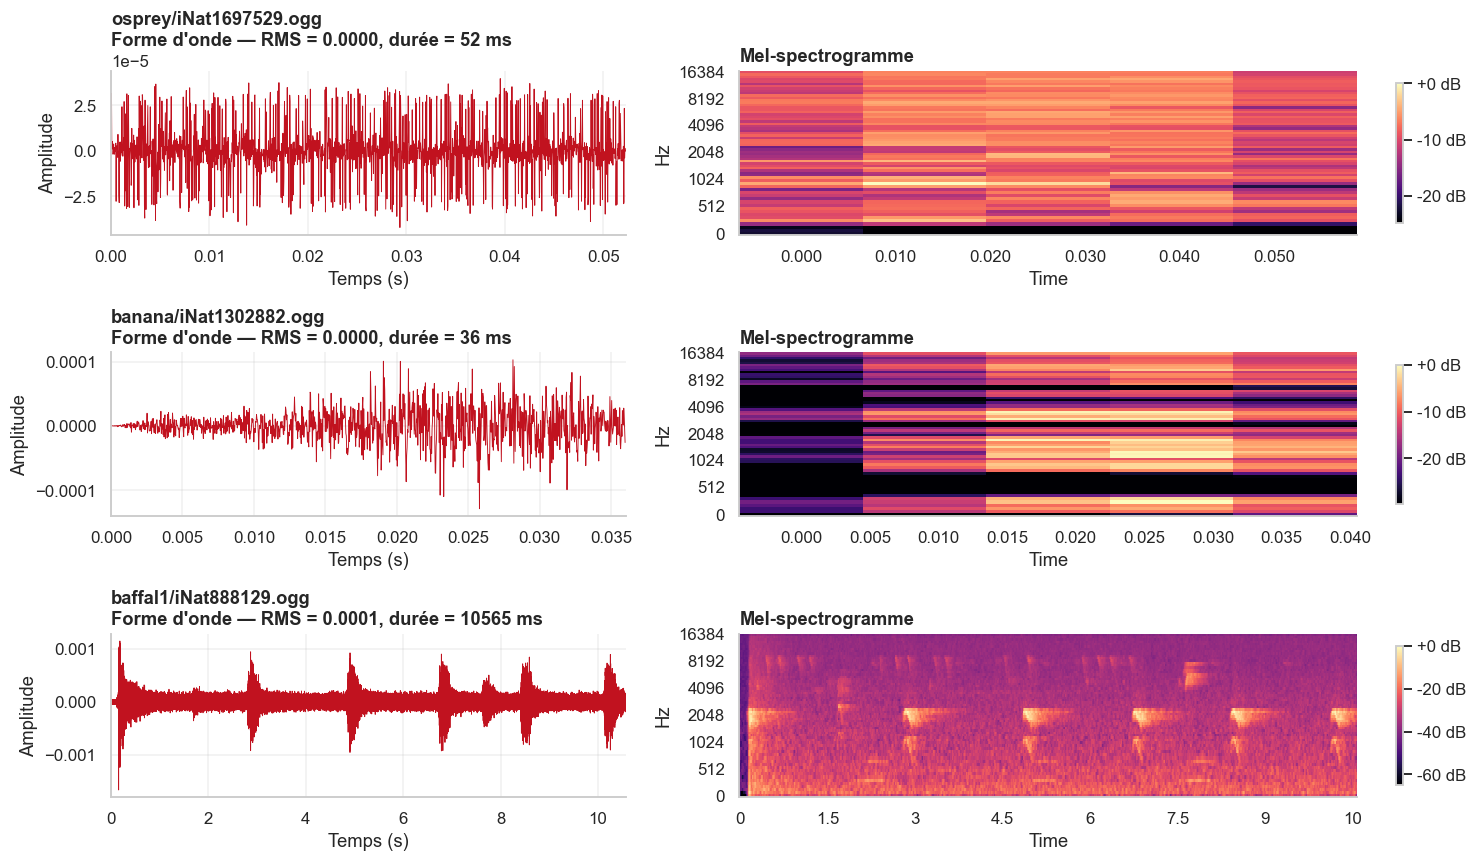

In [27]:
# 4.6 Visualisation des fichiers à RMS quasi nul.
# Confirme visuellement que ce sont bien des fichiers défectueux à flagger ou exclure.

silent_candidates = rms_df.nsmallest(3, 'rms')
print("Trois fichiers avec le RMS le plus bas :")
for _, r in silent_candidates.iterrows():
    dur = audio_meta_df.set_index('filename').loc[r['filename'], 'duration_s']
    print(f"  {r['filename']:<32} RMS = {r['rms']:.6f}  durée = {dur*1000:.0f} ms  classe = {r['class_name']}")

fig, axes = plt.subplots(3, 2, figsize=(14, 8),
                          gridspec_kw={'width_ratios': [1, 1.5]})

for i, (_, r) in enumerate(silent_candidates.iterrows()):
    fname = r['filename']
    path = config.TRAIN_AUDIO_DIR / fname
    y, sr = librosa.load(str(path), sr=None, mono=True)
    duration = len(y) / sr

    ax_w = axes[i, 0]
    times = np.arange(len(y)) / sr
    ax_w.plot(times, y, color='#C1121F', linewidth=0.6)
    ax_w.set_xlim(0, duration if duration > 0 else 0.01)
    ax_w.set_xlabel('Temps (s)')
    ax_w.set_ylabel('Amplitude')
    ax_w.set_title(f'{fname}\nForme d\'onde - RMS = {r["rms"]:.4f}, durée = {duration*1000:.0f} ms', loc='left')
    sns.despine(ax=ax_w)

    ax_s = axes[i, 1]
    # n_fft adapté à la longueur du signal pour éviter les warnings sur signaux très courts
    n_fft = min(2048, max(256, len(y)))
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64, n_fft=n_fft,
                                          hop_length=n_fft // 4, fmax=sr / 2)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    img = librosa.display.specshow(mel_db, sr=sr, x_axis='time', y_axis='mel',
                                    ax=ax_s, cmap='magma', hop_length=n_fft // 4)
    ax_s.set_title('Mel-spectrogramme', loc='left')
    fig.colorbar(img, ax=ax_s, format='%+2.0f dB', shrink=0.85)

plt.tight_layout()
plt.show()

### Observation Section 4

**Format technique**
- 100 % des 35 549 fichiers focaux à 32 kHz, mono, OGG.
- Hypothèses Kaggle confirmées. Aucun resampling, aucune conversion stéréo→mono, aucune gestion de format multiple à prévoir dans le pipeline.
- Taille totale du dataset focal : 10,5 Go (médiane 0,18 Mo par fichier, max 61,3 Mo).

**Durées : trois cas à gérer**
- Distribution très asymétrique : min 0,01 s, médiane 21 s, moyenne 35 s, max 6 881 s (1 h 54 min).
- 2 601 fichiers (7,32 %) sont sous 5 s. Padding zéro pour atteindre la fenêtre cible, sous peine de perdre des espèces rares qui seraient skipées.
- 28 120 fichiers (79,1 %) entre 5 et 60 s : cas standard, 1 à 12 fenêtres 5 s par fichier.
- 4 828 fichiers (13,58 %) au-delà de 60 s, jusqu'à près de 2 heures pour le plus long. Décision : à l'inférence, plafonner à une longueur maximale (par exemple 5 min = 60 fenêtres) ou échantillonner les fenêtres. À l'entraînement, échantillonner une fenêtre aléatoire par epoch fournit une augmentation de données gratuite.

**Niveau sonore (RMS)**
- Mesuré sur les 35 549 fichiers (parallélisation joblib, ~5 min).
- Min 0,0000, médiane 0,0273, max 0,7975. Ratio max/min de 55 376 entre fichiers.
- Normalisation per-file impérative avant extraction de features, sinon les features absolues (énergie, amplitude pic) seront dominées par le volume d'enregistrement plutôt que par le signal acoustique de l'espèce.
- iNat a un signal en médiane deux fois plus faible que XC (0,015 contre 0,034), avec une variabilité deux fois plus grande. Cohérent avec les profils contributeurs (smartphones pour iNat, matériel d'ornithologie pour XC). Comme la collection est elle-même collinéaire avec la classe, attention à ne pas attribuer mécaniquement une faible performance par classe à la classe seule.

**Diversité acoustique par classe taxonomique (figure 4.5)**
- Visualisation d'un fichier représentatif par classe (waveform + mel-spectrogramme).
- Les signatures acoustiques diffèrent radicalement entre groupes : structures harmoniques nettes pour les oiseaux, motifs pulsés pour les amphibiens, stridulations continues à bande étroite pour les insectes, vocalisations plus longues et basses pour les mammifères.
- Conséquence : les features adaptées à un groupe (par exemple les MFCC qui suivent bien les harmoniques d'un chant d'oiseau) ne sont pas nécessairement les meilleures pour un autre (cigales = stridulations larges bandes, plus proches d'un bruit blanc spectralement filtré). Ce constat justifie d'extraire un jeu de features varié (temporelles, spectrales, MFCC, indices bioacoustiques) plutôt que de se limiter aux MFCC.

**Fichiers à signal nul ou quasi nul (figure 4.6)**
- 312 fichiers (0,88 %) ont un RMS inférieur à 0,001, c'est-à-dire un signal acoustique quasi inexistant.
- Visualisation des trois fichiers au RMS le plus bas : deux d'entre eux durent 36 et 52 ms (fichiers tronqués), le troisième dure 10,5 s mais avec un signal effectivement quasi inaudible. Les trois sont des Aves issus d'iNaturalist, ce qui suggère une concentration des fichiers défectueux côté iNat (uploads de contributeurs grand public).
- Décision : flagger systématiquement les 312 fichiers au RMS < 0,001, puis les exclure de l'entraînement et de l'inférence.

## Section 5. Soundscapes annotés et non annotés

Le dossier `train_soundscapes/` contient deux pools de natures très différentes : un petit pool annoté par des experts (66 fichiers, 1 478 fenêtres de 5 secondes labellisées en multi-label), et un grand pool non annoté (le reste, exploité de façon non-supervisée). La section caractérise les deux : volume relatif, multi-label réel observé par fenêtre, espèces qui n'apparaissent que dans les soundscapes, propriétés techniques (durée, format) des fichiers, et distribution temporelle (heures et dates d'enregistrement). L'objectif est de quantifier d'une part la richesse acoustique du domaine cible, d'autre part la ressource disponible pour du pseudo-labeling éventuel.

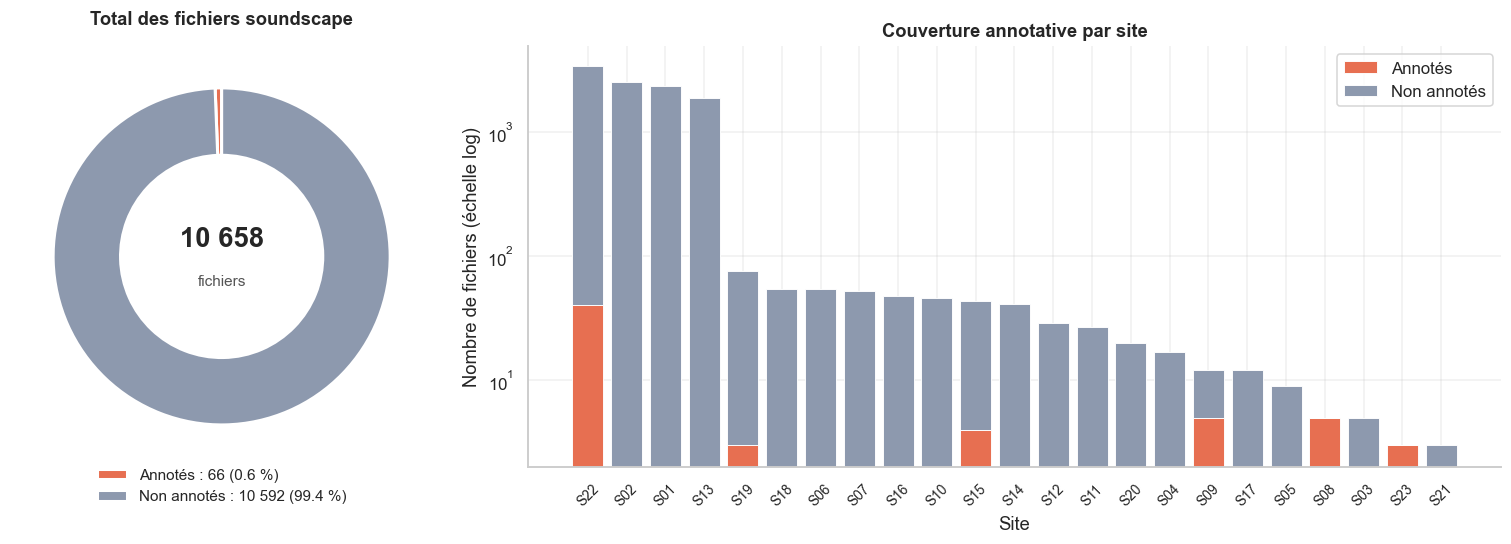

Total fichiers soundscape : 10 658
Annotés                   : 66 (0.62 %)
Non annotés               : 10 592 (99.38 %)
Annotations expert        : 1 478 fenêtres 5 s


In [28]:
# 5.1 Vue d'ensemble : fichiers annotés vs non annotés.
import re
all_sound_files = sorted(p.name for p in Path(config.TRAIN_SOUNDSCAPES_DIR).glob('*.ogg'))
annotated_files = set(soundscapes_df['filename'].unique())
n_annot   = sum(1 for f in all_sound_files if f in annotated_files)
n_all     = len(all_sound_files)
n_unannot = n_all - n_annot

def extract_site(fname):
    m = re.search(r'_S(\d+)_', fname)
    return f"S{m.group(1)}" if m else None

# Comptes par site
from collections import Counter
site_total = Counter(extract_site(f) for f in all_sound_files if extract_site(f))
site_annot = Counter(extract_site(f) for f in annotated_files if extract_site(f))
sites_sorted = sorted(site_total.keys(), key=lambda s: -site_total[s])
totals  = [site_total[s] for s in sites_sorted]
annots  = [site_annot.get(s, 0) for s in sites_sorted]
unannots = [t - a for t, a in zip(totals, annots)]

# Figure : donut global + stacked bar par site
fig, axes = plt.subplots(1, 2, figsize=(14, 5),
                          gridspec_kw={'width_ratios': [1, 2.2]})

ax = axes[0]
wedges, _ = ax.pie([n_annot, n_unannot],
                    colors=['#E76F51', '#8D99AE'],
                    startangle=90,
                    wedgeprops={'width': 0.4, 'edgecolor': 'white', 'linewidth': 2})
# Labels au centre + à côté
ax.text(0, 0.1, f'{n_all:,}'.replace(',', ' '), ha='center', va='center', fontsize=18, fontweight='bold')
ax.text(0, -0.15, 'fichiers', ha='center', va='center', fontsize=10, color='#555')
ax.legend(wedges,
          [f'Annotés : {n_annot} ({n_annot/n_all*100:.1f} %)',
           f'Non annotés : {n_unannot:,} ({n_unannot/n_all*100:.1f} %)'.replace(',', ' ')],
          loc='lower center', bbox_to_anchor=(0.5, -0.12), fontsize=10, frameon=False)
ax.set_title("Total des fichiers soundscape", pad=14)

ax = axes[1]
ax.bar(sites_sorted, annots, color='#E76F51', edgecolor='white', linewidth=0.6, label='Annotés')
ax.bar(sites_sorted, unannots, bottom=annots, color='#8D99AE', edgecolor='white', linewidth=0.6, label='Non annotés')
ax.set_yscale('log')
ax.set_xlabel('Site')
ax.set_ylabel('Nombre de fichiers (échelle log)')
ax.set_title('Couverture annotative par site')
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.legend(loc='upper right', frameon=True)
sns.despine(ax=ax)

plt.tight_layout()
plt.show()

print(f"Total fichiers soundscape : {n_all:,}".replace(',', ' '))
print(f"Annotés                   : {n_annot} ({n_annot/n_all*100:.2f} %)")
print(f"Non annotés               : {n_unannot:,} ({n_unannot/n_all*100:.2f} %)".replace(',', ' '))
print(f"Annotations expert        : {len(soundscapes_df):,} fenêtres 5 s".replace(',', ' '))

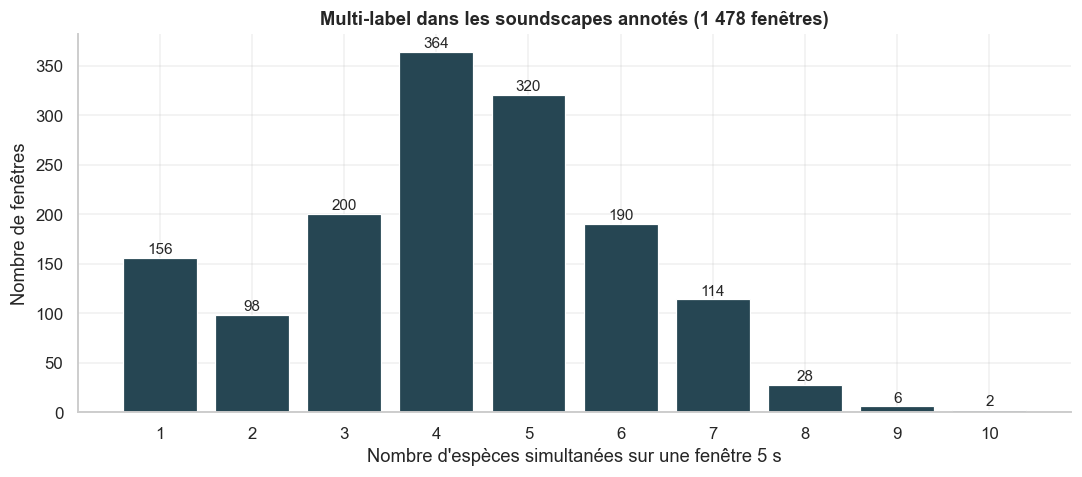

Espèces simultanées par fenêtre : médiane 4, moyenne 4.22
Min : 1, Max : 10
Fenêtres mono-espèce  : 156 (10.6 %)
Fenêtres avec 5+ espèces : 660


In [29]:
# 5.2 Multi-label réel observé : nombre d'espèces simultanées par fenêtre 5 s.
soundscapes_df['n_species_in_window'] = soundscapes_df['primary_label'].str.split(';').str.len()
n_species_dist = soundscapes_df['n_species_in_window'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 4.5))
bars = ax.bar(n_species_dist.index, n_species_dist.values,
              color='#264653', edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, n_species_dist.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + max(n_species_dist.values) * 0.012,
            f'{val:,}'.replace(',', ' '), ha='center', fontsize=10)
ax.set_xlabel("Nombre d'espèces simultanées sur une fenêtre 5 s")
ax.set_ylabel("Nombre de fenêtres")
ax.set_title(f"Multi-label dans les soundscapes annotés ({len(soundscapes_df):,} fenêtres)".replace(',', ' '))
ax.set_xticks(n_species_dist.index)
sns.despine()
plt.tight_layout()
plt.show()

print(f"Espèces simultanées par fenêtre : médiane {soundscapes_df['n_species_in_window'].median():.0f}, "
      f"moyenne {soundscapes_df['n_species_in_window'].mean():.2f}")
print(f"Min : {soundscapes_df['n_species_in_window'].min()}, "
      f"Max : {soundscapes_df['n_species_in_window'].max()}")
print(f"Fenêtres mono-espèce  : {(soundscapes_df['n_species_in_window'] == 1).sum():,} "
      f"({(soundscapes_df['n_species_in_window'] == 1).mean() * 100:.1f} %)".replace(',', ' '))
print(f"Fenêtres avec 5+ espèces : {(soundscapes_df['n_species_in_window'] >= 5).sum():,}".replace(',', ' '))

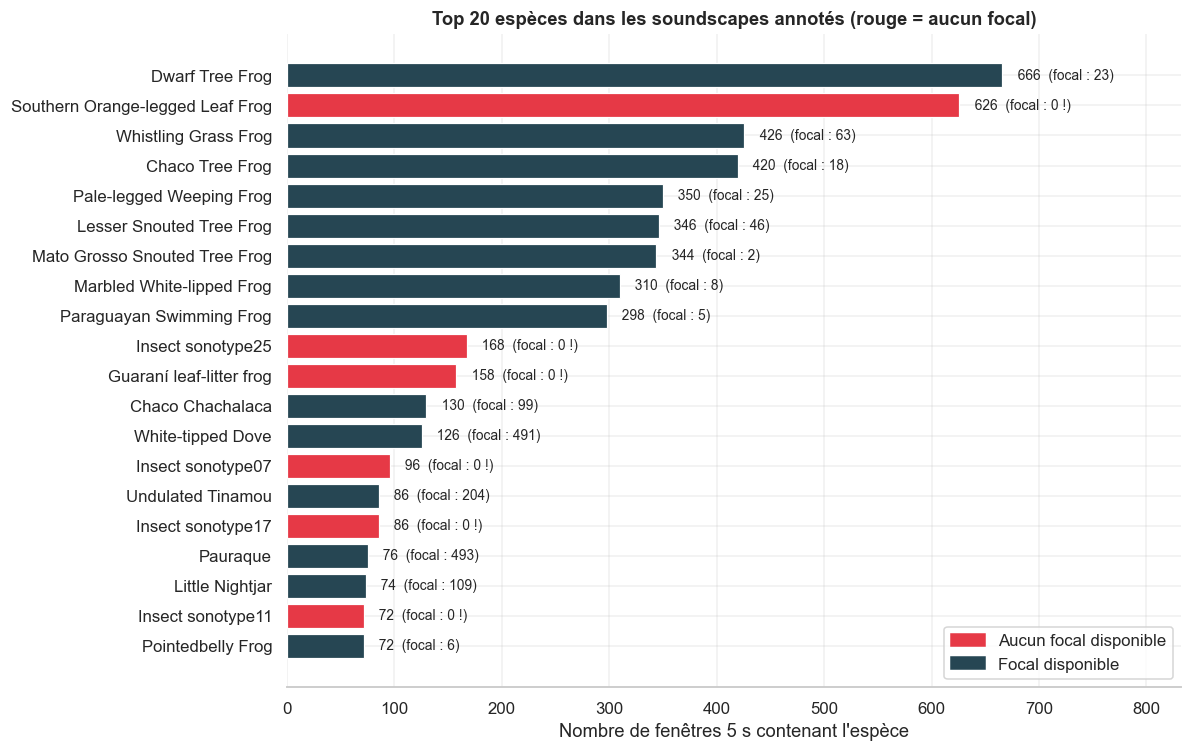

Dans le top 20 soundscape : 6 espèces n'ont aucun fichier focal.
Au total (Section 1) : 28 espèces sont uniquement présentes en soundscape.


In [30]:
# 5.3 Top espèces en soundscape, en distinguant celles présentes ou non en focal.
sound_species_exploded = soundscapes_df['primary_label'].str.split(';').explode().str.strip()
sound_freq = sound_species_exploded.value_counts()

top_sound = sound_freq.head(20).reset_index()
top_sound.columns = ['primary_label', 'n_sound_windows']
top_sound = top_sound.merge(
    species_df[['primary_label', 'common_name', 'class_name', 'n_focal']],
    on='primary_label', how='left'
)
# Marquer les espèces uniquement soundscape (n_focal == 0)
top_sound['only_sound'] = top_sound['n_focal'] == 0

fig, ax = plt.subplots(figsize=(11, 7))
colors = ['#E63946' if o else '#264653' for o in top_sound['only_sound'][::-1]]
labels = top_sound['common_name'][::-1]
values = top_sound['n_sound_windows'][::-1].values
ax.barh(labels, values, color=colors, edgecolor='white', linewidth=0.8)
for i, (v, n_f, only) in enumerate(zip(values,
                                        top_sound['n_focal'][::-1].astype(int),
                                        top_sound['only_sound'][::-1])):
    annot = f'  {v}  (focal : {n_f})' if not only else f'  {v}  (focal : 0 !)'
    ax.text(v + max(values) * 0.01, i, annot, va='center', fontsize=9)
ax.set_title("Top 20 espèces dans les soundscapes annotés (rouge = aucun focal)")
ax.set_xlabel("Nombre de fenêtres 5 s contenant l'espèce")
ax.set_xlim(0, max(values) * 1.25)

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#E63946', label='Aucun focal disponible'),
                    Patch(color='#264653', label='Focal disponible')],
          loc='lower right', frameon=True)
sns.despine(left=True)
plt.tight_layout()
plt.show()

n_only_sound_top = top_sound['only_sound'].sum()
n_only_sound_total = (species_df['n_focal'] == 0).sum()
print(f"Dans le top 20 soundscape : {n_only_sound_top} espèces n'ont aucun fichier focal.")
print(f"Au total (Section 1) : {n_only_sound_total} espèces sont uniquement présentes en soundscape.")

In [31]:
# 5.4 Propriétés techniques de tous les fichiers soundscape (annotés + non annotés).
# Métadonnées via sf.info (rapide, parallélisé).
def get_sound_meta(fname):
    path = config.TRAIN_SOUNDSCAPES_DIR / fname
    try:
        info = sf.info(str(path))
        return {'filename': fname,
                'duration_s': info.duration,
                'sample_rate': info.samplerate,
                'channels': info.channels,
                'size_bytes': path.stat().st_size}
    except Exception as e:
        return {'filename': fname, 'error': str(e)}

sound_meta_results = Parallel(n_jobs=-1, backend='threading')(
    delayed(get_sound_meta)(f) for f in tqdm(all_sound_files, desc='Soundscape meta')
)
sound_meta_df = pd.DataFrame(sound_meta_results)
print(f"Fichiers analysés sans erreur : {len(sound_meta_df):,} / {len(all_sound_files):,}".replace(',', ' '))
print()
print("Sample rates :", sound_meta_df['sample_rate'].value_counts().to_dict())
print("Canaux       :", sound_meta_df['channels'].value_counts().to_dict())
print()
print("Durées (s) :")
print(f"  min     : {sound_meta_df['duration_s'].min():.1f}")
print(f"  médiane : {sound_meta_df['duration_s'].median():.1f}")
print(f"  moyenne : {sound_meta_df['duration_s'].mean():.1f}")
print(f"  max     : {sound_meta_df['duration_s'].max():.1f}")
print(f"  total   : {sound_meta_df['duration_s'].sum() / 3600:.1f} heures cumulées")

Soundscape meta:   0%|          | 0/10658 [00:00<?, ?it/s]

Fichiers analysés sans erreur : 10 658 / 10 658

Sample rates : {32000: 10658}
Canaux       : {1: 10658}

Durées (s) :
  min     : 60.0
  médiane : 60.0
  moyenne : 60.0
  max     : 60.0
  total   : 177.6 heures cumulées


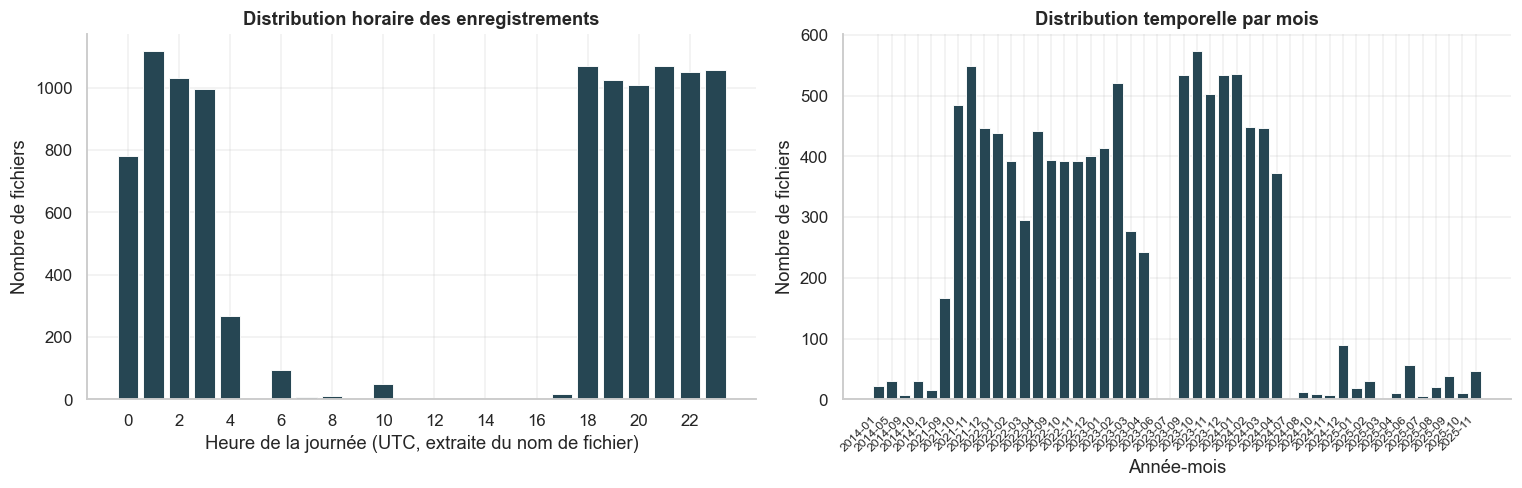

Fichiers avec timestamp extractible : 10 658 / 10 658
Plage temporelle observée : 2014-01-07 21:01:00 → 2025-11-29 10:26:00
Nombre de mois distincts  : 46


In [32]:
# 5.5 Distribution temporelle : heure de la journée et période d'enregistrement.
from datetime import datetime

def extract_datetime(fname):
    m = re.search(r'_(\d{8})_(\d{6})\.ogg', fname)
    if not m:
        return None
    try:
        return datetime.strptime(m.group(1) + m.group(2), '%Y%m%d%H%M%S')
    except ValueError:
        return None

sound_meta_df['datetime'] = sound_meta_df['filename'].apply(extract_datetime)
sound_meta_df['hour']     = sound_meta_df['datetime'].apply(lambda x: x.hour if x else None)
sound_meta_df['ym']       = sound_meta_df['datetime'].apply(lambda x: x.strftime('%Y-%m') if x else None)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))

# Heure de la journée
ax = axes[0]
hour_counts = sound_meta_df['hour'].value_counts().sort_index()
ax.bar(hour_counts.index, hour_counts.values, color='#264653', edgecolor='white', linewidth=0.6)
ax.set_xlabel('Heure de la journée (UTC, extraite du nom de fichier)')
ax.set_ylabel('Nombre de fichiers')
ax.set_title('Distribution horaire des enregistrements')
ax.set_xticks(range(0, 24, 2))
sns.despine(ax=ax)

# Distribution mensuelle
ax = axes[1]
ym_counts = sound_meta_df['ym'].value_counts().sort_index()
ax.bar(range(len(ym_counts)), ym_counts.values, color='#264653', edgecolor='white', linewidth=0.6)
ax.set_xticks(range(len(ym_counts)))
ax.set_xticklabels(ym_counts.index, rotation=45, ha='right', fontsize=8)
ax.set_xlabel('Année-mois')
ax.set_ylabel('Nombre de fichiers')
ax.set_title('Distribution temporelle par mois')
sns.despine(ax=ax)

plt.tight_layout()
plt.show()

print(f"Fichiers avec timestamp extractible : {sound_meta_df['datetime'].notna().sum():,} / {len(sound_meta_df):,}".replace(',', ' '))
if sound_meta_df['datetime'].notna().any():
    dt_min = sound_meta_df['datetime'].min()
    dt_max = sound_meta_df['datetime'].max()
    print(f"Plage temporelle observée : {dt_min} → {dt_max}")
    print(f"Nombre de mois distincts  : {sound_meta_df['ym'].nunique()}")

### Observation Section 5

**Pool annoté minuscule**
- Seulement 66 fichiers annotés sur 10 658 (0,62 %). Les 10 592 fichiers restants forment la ressource non-supervisée pour pseudo-labeling éventuel.
- 1 478 fenêtres 5 s avec labels expert au total.

**Multi-label intense, c'est la nature du test**
- Médiane de 4 espèces simultanées par fenêtre 5 s, moyenne 4,22, maximum 10.
- 89,4 % des fenêtres soundscape contiennent au moins deux espèces. Seules 156 fenêtres (10,6 %) sont mono-espèce.
- Conséquences modélisation : entraînement obligatoirement multi-label, sigmoïde indépendante par classe (pas softmax), et le seuil de décision par espèce doit être bas. Entraîner en mono-label sur le focal reviendrait à apprendre l'inverse de ce que le test demande.

**Espèces uniquement présentes en soundscape**
- Dans le top 20 des espèces les plus fréquentes en soundscape, 6 n'ont aucun fichier focal disponible. Confirmation des 28 espèces sans focal identifiées en Section 1.
- Ces espèces sont régulièrement audibles dans le contexte cible mais ne peuvent pas être apprises par la piste stricte. Justification supplémentaire pour la piste hybride (embeddings pré-entraînés) ou l'exploitation directe des annotations soundscape comme données d'entraînement.

**Durée uniforme et pipeline d'inférence trivial**
- Tous les soundscapes font exactement 60,0 secondes, 32 kHz, mono, OGG.
- À l'inférence sur le test (mêmes propriétés annoncées), chaque fichier produit exactement 12 fenêtres 5 s. Aucun edge case à gérer comme sur le focal (fichiers très courts ou très longs).

**Couverture temporelle large**
- 11 ans de couverture (2014-01-07 à 2025-11-29), 46 mois distincts.
- 177,6 heures cumulées d'audio soundscape disponibles.
- Aucune feature temporelle (heure, mois) n'est utilisable comme prédicteur direct sur le test (le test cache cette info). En analyse d'erreurs, on pourra ventiler les performances par heure pour vérifier si les espèces nocturnes posent un problème particulier.

## Section 6. Comparaison focal vs soundscape

Le modèle est entraîné sur des fichiers focaux (signal centré sur une espèce, qualité d'enregistrement variable mais souvent élevée) et évalué sur des fenêtres 5 s de soundscape (signal in situ, multi-espèces, bruit de fond ambiant). La section quantifie le *domain gap* entre ces deux distributions acoustiques : comparaison visuelle (waveforms et mel-spectrogrammes côte à côte), comparaison quantitative des features bas niveau (RMS, centroïde spectral, taux de passage par zéro, entropie spectrale), et projection 2D par PCA pour visualiser la séparation des deux pools. Toutes les comparaisons sont faites à granularité égale (fenêtres 5 s pour les deux), ce qui correspond exactement à ce que le pipeline d'inférence rencontrera.

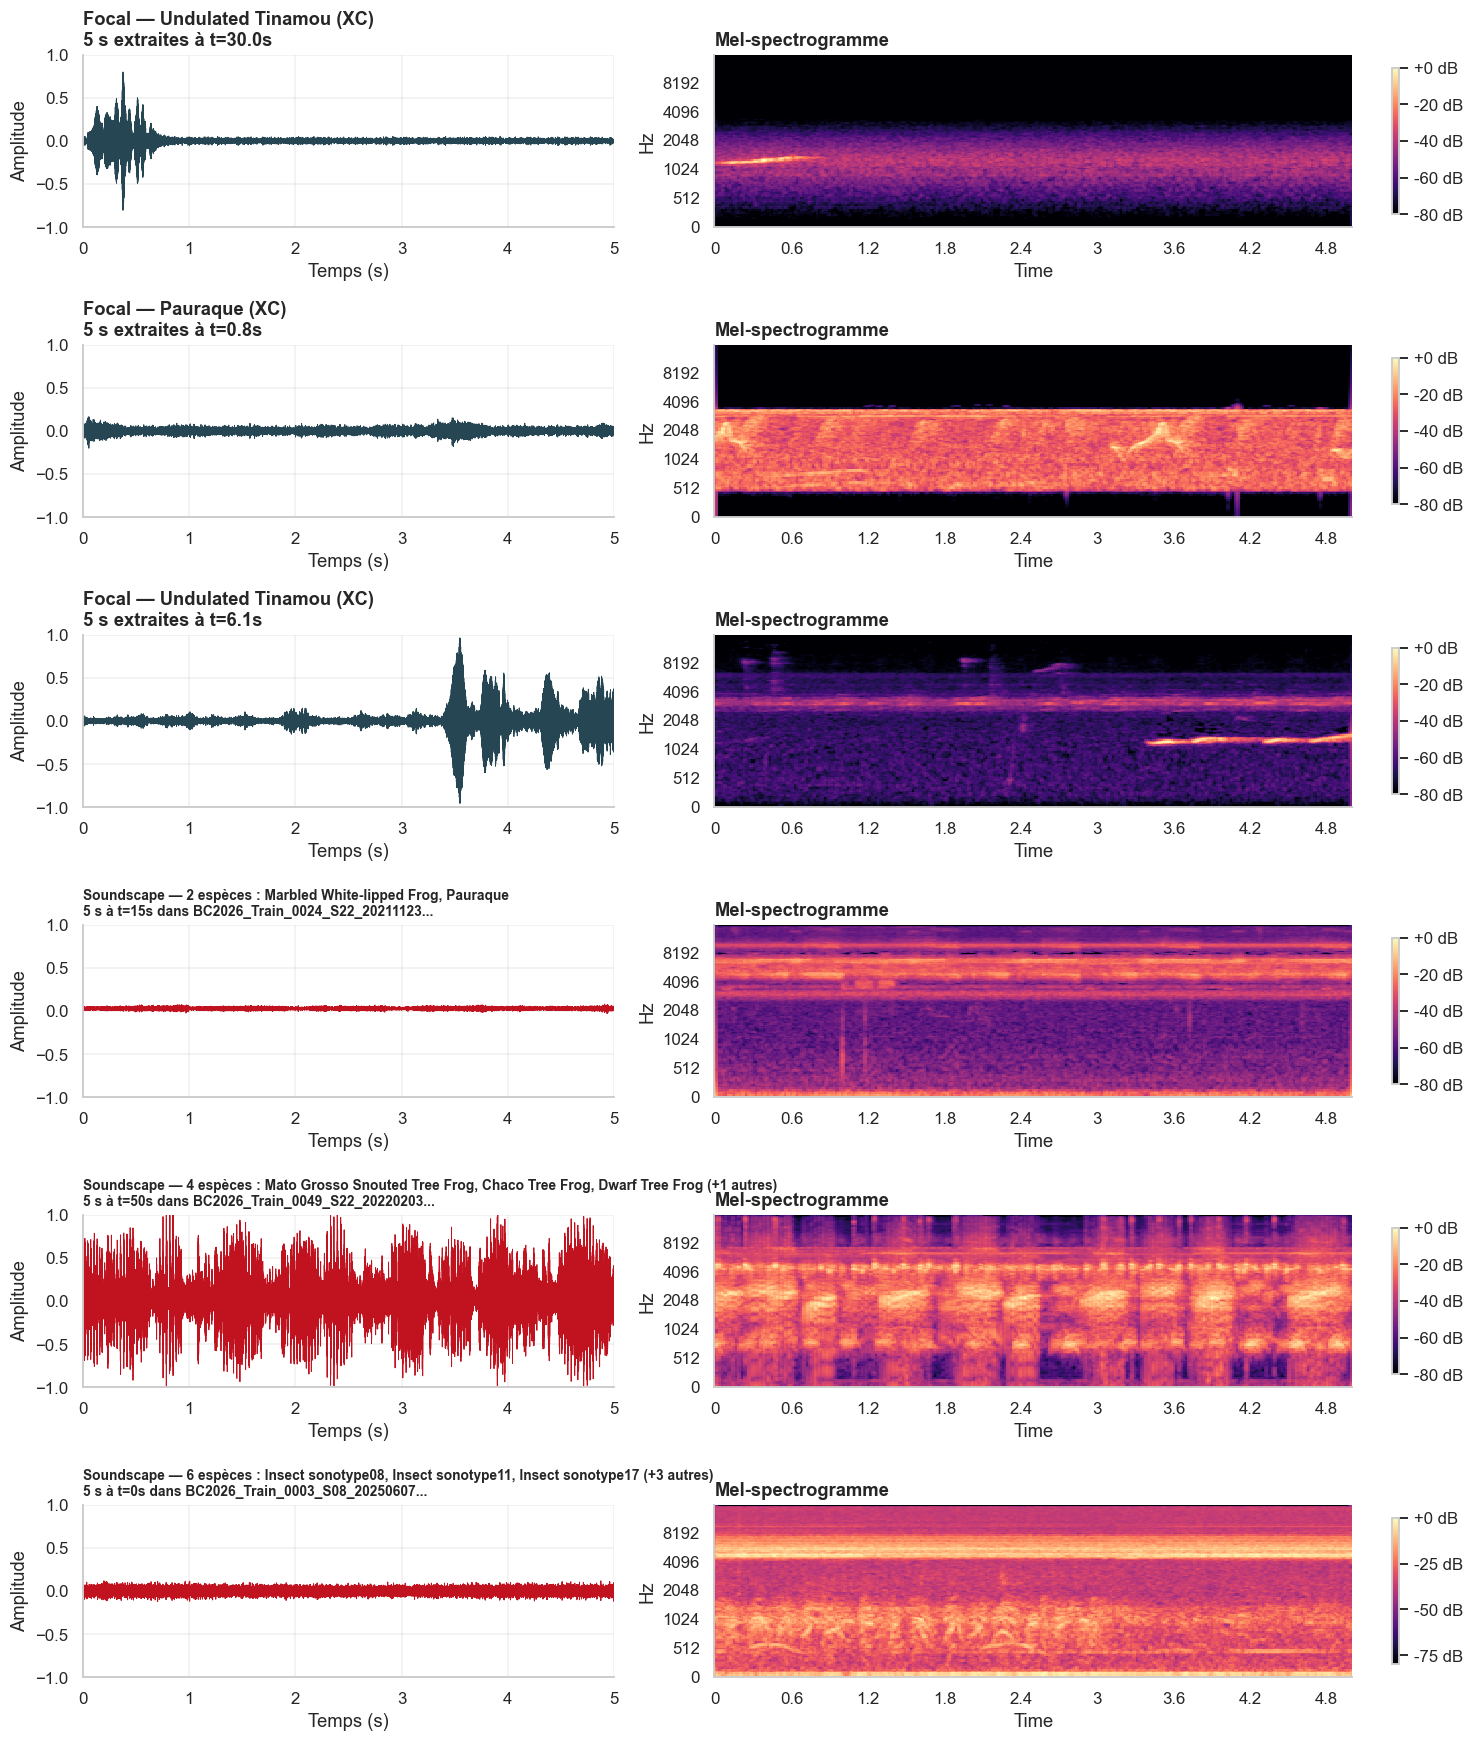


Écoute :
  • Focal - Undulated Tinamou (XC)


  • Focal - Pauraque (XC)


  • Focal - Undulated Tinamou (XC)


  • Soundscape - 2 espèces : Marbled White-lipped Frog, Pauraque


  • Soundscape - 4 espèces : Mato Grosso Snouted Tree Frog, Chaco Tree Frog, Dwarf Tree Frog (+1 autres)


  • Soundscape - 6 espèces : Insect sonotype08, Insect sonotype11, Insect sonotype17 (+3 autres)


In [33]:
# 6.1 Comparaison visuelle : 3 focaux (5 s extraits) vs 3 soundscapes annotés (5 s).
# Les soundscapes sont pris parmi les annotés pour connaître les espèces présentes.
# Les focaux sont pris parmi des espèces fréquentes en soundscape pour un parallèle thématique.

import librosa.display
from IPython.display import Audio, display

rng_viz = np.random.default_rng(config.RANDOM_SEED)

# 3 focaux choisis parmi des espèces présentes en soundscape
focal_examples = (
    train_df[train_df['primary_label'].isin(sound_freq.head(20).index) &
             (train_df['filename'].isin(audio_meta_df.loc[audio_meta_df['duration_s'] >= 5, 'filename']))]
    .sample(n=3, random_state=config.RANDOM_SEED)
)

# 3 soundscapes annotés tirés au hasard
sound_examples = soundscapes_df.sample(n=3, random_state=config.RANDOM_SEED)

fig, axes = plt.subplots(6, 2, figsize=(14, 16),
                          gridspec_kw={'width_ratios': [1, 1.5]})

def parse_ts(s):
    """Convertit '00:01:30' en secondes (int)."""
    h, m, sec = s.split(':')
    return int(h) * 3600 + int(m) * 60 + int(sec)

def lookup_name(code):
    row = species_df[species_df['primary_label'] == code]
    return row.iloc[0]['common_name'] if len(row) else code

audio_widgets = []

# 3 focaux : extraire une fenêtre 5 s à un offset aléatoire dans le fichier
for i, (_, row) in enumerate(focal_examples.iterrows()):
    fname = row['filename']
    path = config.TRAIN_AUDIO_DIR / fname
    full_dur = audio_meta_df.set_index('filename').loc[fname, 'duration_s']
    offset = float(rng_viz.uniform(0, max(0.01, full_dur - 5)))
    y, sr = librosa.load(str(path), sr=None, mono=True, offset=offset, duration=5.0)
    title = f"Focal - {lookup_name(row['primary_label'])} ({row['collection']})"
    
    ax_w = axes[i, 0]
    times = np.arange(len(y)) / sr
    ax_w.plot(times, y, color='#264653', linewidth=0.6)
    ax_w.set_xlim(0, 5)
    ax_w.set_ylim(-1, 1)
    ax_w.set_xlabel('Temps (s)')
    ax_w.set_ylabel('Amplitude')
    ax_w.set_title(f'{title}\n5 s extraites à t={offset:.1f}s', loc='left')
    sns.despine(ax=ax_w)
    
    ax_s = axes[i, 1]
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=sr / 2)
    img = librosa.display.specshow(librosa.power_to_db(mel, ref=np.max),
                                    sr=sr, x_axis='time', y_axis='mel',
                                    ax=ax_s, cmap='magma')
    ax_s.set_title('Mel-spectrogramme', loc='left')
    fig.colorbar(img, ax=ax_s, format='%+2.0f dB', shrink=0.85)
    audio_widgets.append((title, y, sr))

# 3 soundscapes : extraire la fenêtre 5 s correspondant à l'annotation
for i, (_, row) in enumerate(sound_examples.iterrows()):
    fname  = row['filename']
    start  = parse_ts(row['start'])
    path   = config.TRAIN_SOUNDSCAPES_DIR / fname
    y, sr  = librosa.load(str(path), sr=None, mono=True, offset=start, duration=5.0)
    codes  = row['primary_label'].split(';')
    names  = ', '.join(lookup_name(c) for c in codes[:3])
    if len(codes) > 3:
        names += f' (+{len(codes)-3} autres)'
    title = f"Soundscape - {len(codes)} espèces : {names}"
    
    ax_w = axes[3 + i, 0]
    times = np.arange(len(y)) / sr
    ax_w.plot(times, y, color='#C1121F', linewidth=0.6)
    ax_w.set_xlim(0, 5)
    ax_w.set_ylim(-1, 1)
    ax_w.set_xlabel('Temps (s)')
    ax_w.set_ylabel('Amplitude')
    ax_w.set_title(f'{title}\n5 s à t={start}s dans {fname[:30]}...', loc='left', fontsize=9)
    sns.despine(ax=ax_w)
    
    ax_s = axes[3 + i, 1]
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=sr / 2)
    img = librosa.display.specshow(librosa.power_to_db(mel, ref=np.max),
                                    sr=sr, x_axis='time', y_axis='mel',
                                    ax=ax_s, cmap='magma')
    ax_s.set_title('Mel-spectrogramme', loc='left')
    fig.colorbar(img, ax=ax_s, format='%+2.0f dB', shrink=0.85)
    audio_widgets.append((title, y, sr))

plt.tight_layout()
plt.show()

# Widgets d'écoute (visibles dans le notebook ; n'apparaissent pas dans un export PDF).
print("\nÉcoute :")
for title, y, sr in audio_widgets:
    print(f"  • {title}")
    display(Audio(y, rate=sr))

Focal 5s:   0%|          | 0/500 [00:00<?, ?it/s]

Soundscape 5s:   0%|          | 0/500 [00:00<?, ?it/s]

Fenêtres exploitables : 1000 (focal 500, soundscape 500)


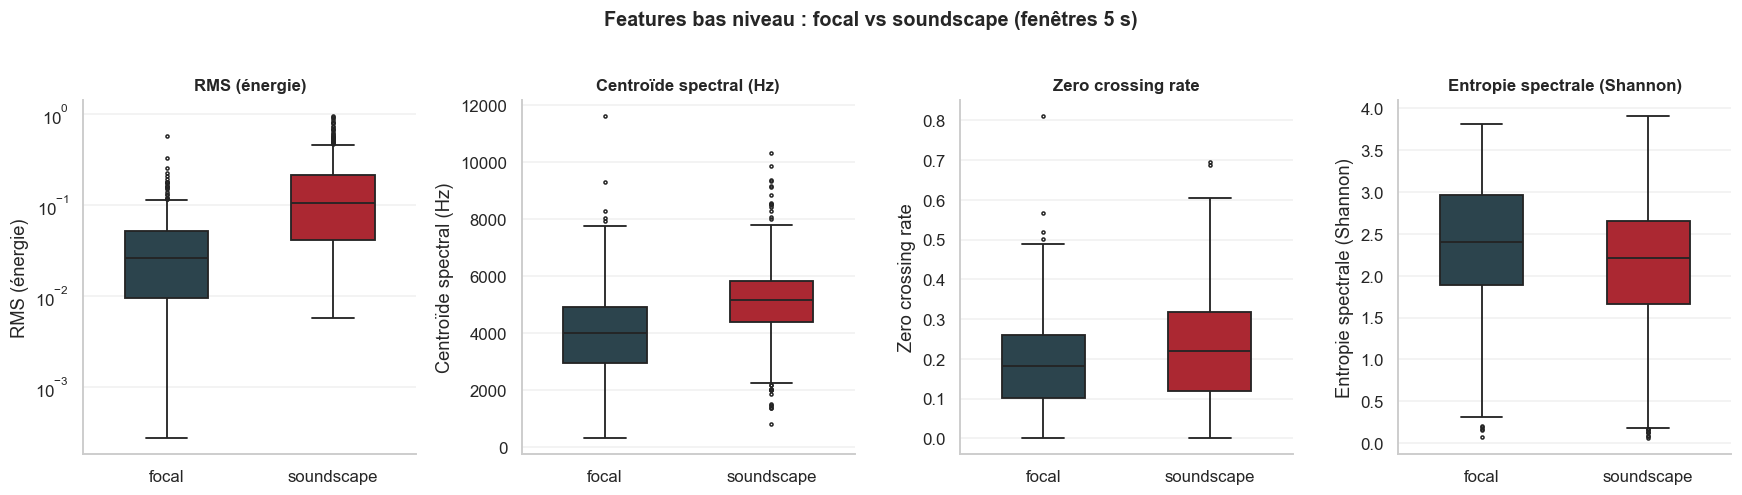


Médianes par origine :
              rms   centroid     zcr  spec_entropy
origin                                            
focal       0.026  4013.8246  0.1808        2.3992
soundscape  0.106  5172.9565  0.2193        2.2170

Test de Mann-Whitney (H0 : distributions identiques) :
  rms             U =      46646  p = 5.49e-66
  centroid        U =      68936  p = 1.21e-34
  zcr             U =     107522  p = 1.30e-04
  spec_entropy    U =     146830  p = 1.75e-06


In [34]:
# 6.2 Comparaison quantitative : extraction de 4 features bas niveau
# sur 500 fenêtres 5 s aléatoires pour chaque pool (focal et soundscape).
# Features choisies pour caractériser l'écart de domaine :
#  - RMS : énergie globale du signal.
#  - Spectral centroid : centre de masse fréquentiel (perception graves/aigus).
#  - Zero crossing rate : taux de passage par zéro (tonal vs bruité).
#  - Spectral entropy : complexité spectrale (multi-source vs signal pur).

import scipy.stats

N_SAMPLES = 500
WIN = 5.0  # secondes

rng_q = np.random.default_rng(config.RANDOM_SEED)

# Échantillon focal : fenêtres 5 s aléatoires (durée minimale 5 s)
focal_pool = audio_meta_df[audio_meta_df['duration_s'] >= WIN].sample(
    n=N_SAMPLES, random_state=config.RANDOM_SEED)
# Échantillon soundscape : fenêtres 5 s aléatoires (tous les fichiers soundscape, pas seulement les annotés)
sound_files_5s = sound_meta_df[sound_meta_df['duration_s'] >= WIN]
sound_pool = sound_files_5s.sample(n=N_SAMPLES, random_state=config.RANDOM_SEED)

def features_for_clip(y, sr):
    if len(y) < sr:
        return None
    rms = float(np.sqrt(np.mean(y ** 2)))
    centroid = float(np.mean(librosa.feature.spectral_centroid(y=y, sr=sr)))
    zcr      = float(np.mean(librosa.feature.zero_crossing_rate(y=y)))
    # Entropie spectrale : entropie de Shannon de la distribution d'énergie sur les bandes mel.
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64).mean(axis=1)
    p = mel / (mel.sum() + 1e-12)
    spec_entropy = float(scipy.stats.entropy(p))
    return {'rms': rms, 'centroid': centroid, 'zcr': zcr, 'spec_entropy': spec_entropy}

def extract_focal(row):
    fname = row['filename']
    path  = config.TRAIN_AUDIO_DIR / fname
    full_dur = row['duration_s']
    offset = float(rng_q.uniform(0, max(0.01, full_dur - WIN)))
    try:
        y, sr = librosa.load(str(path), sr=None, mono=True, offset=offset, duration=WIN)
        feats = features_for_clip(y, sr)
        return {'origin': 'focal', **feats} if feats else None
    except Exception:
        return None

def extract_soundscape(row):
    fname = row['filename']
    path  = config.TRAIN_SOUNDSCAPES_DIR / fname
    offset = float(rng_q.uniform(0, max(0.01, row['duration_s'] - WIN)))
    try:
        y, sr = librosa.load(str(path), sr=None, mono=True, offset=offset, duration=WIN)
        feats = features_for_clip(y, sr)
        return {'origin': 'soundscape', **feats} if feats else None
    except Exception:
        return None

focal_feats = Parallel(n_jobs=-1, backend='threading')(
    delayed(extract_focal)(row) for _, row in tqdm(focal_pool.iterrows(),
                                                     total=len(focal_pool), desc='Focal 5s'))
sound_feats = Parallel(n_jobs=-1, backend='threading')(
    delayed(extract_soundscape)(row) for _, row in tqdm(sound_pool.iterrows(),
                                                          total=len(sound_pool), desc='Soundscape 5s'))

compare_df = pd.DataFrame([x for x in focal_feats + sound_feats if x is not None])
print(f"Fenêtres exploitables : {len(compare_df)} "
      f"(focal {(compare_df['origin']=='focal').sum()}, "
      f"soundscape {(compare_df['origin']=='soundscape').sum()})")

# Figure 4 panels (boxplots côte à côte)
fig, axes = plt.subplots(1, 4, figsize=(16, 4.4))
colors_origin = {'focal': '#264653', 'soundscape': '#C1121F'}
feat_labels = {
    'rms': 'RMS (énergie)',
    'centroid': 'Centroïde spectral (Hz)',
    'zcr': 'Zero crossing rate',
    'spec_entropy': 'Entropie spectrale (Shannon)',
}
for ax, (feat, label) in zip(axes, feat_labels.items()):
    sns.boxplot(x='origin', y=feat, hue='origin', data=compare_df,
                ax=ax, palette=colors_origin, width=0.5,
                linewidth=1.2, fliersize=2, legend=False,
                order=['focal', 'soundscape'])
    ax.set_ylabel(label)
    ax.set_xlabel('')
    ax.set_title(label, fontsize=11)
    if feat == 'rms':
        ax.set_yscale('log')
    sns.despine(ax=ax)
fig.suptitle("Features bas niveau : focal vs soundscape (fenêtres 5 s)", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Statistiques résumées + tests de Mann-Whitney pour chaque feature
print("\nMédianes par origine :")
print(compare_df.groupby('origin')[list(feat_labels)].median().round(4).to_string())
print()
print("Test de Mann-Whitney (H0 : distributions identiques) :")
for feat in feat_labels:
    f_vals = compare_df.loc[compare_df['origin'] == 'focal', feat]
    s_vals = compare_df.loc[compare_df['origin'] == 'soundscape', feat]
    u, p = scipy.stats.mannwhitneyu(f_vals, s_vals, alternative='two-sided')
    print(f"  {feat:<14}  U = {u:>10.0f}  p = {p:.2e}")

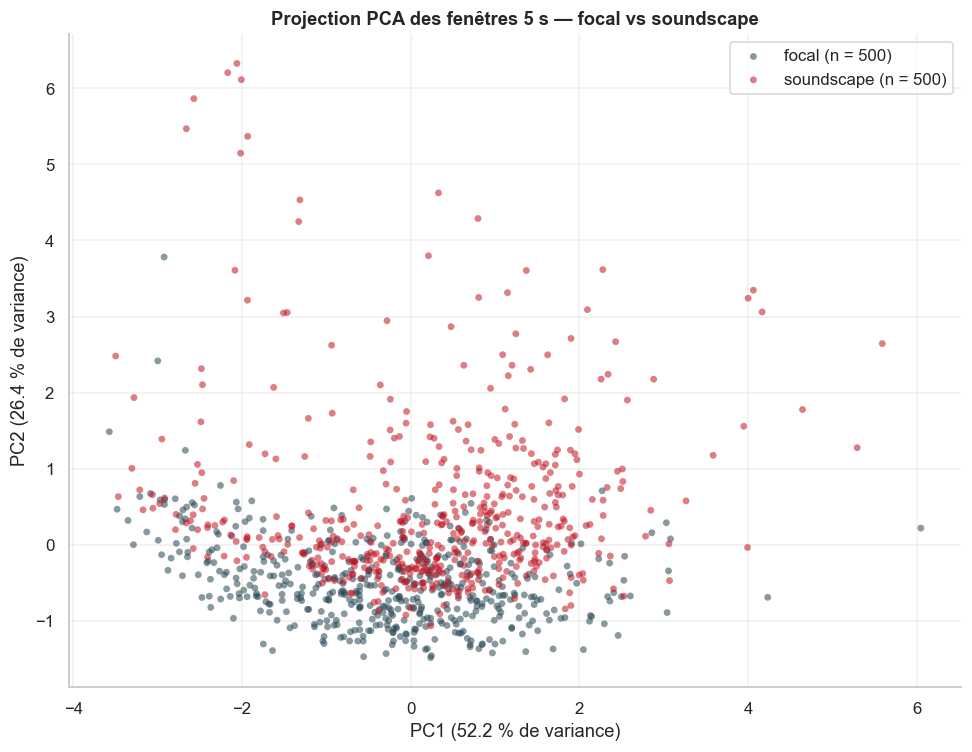

Variance expliquée : PC1 = 52.2 %, PC2 = 26.4 %, total = 78.6 %

Loadings (contribution de chaque feature aux axes principaux) :
                PC1    PC2
rms           0.110  0.892
centroid      0.617  0.082
zcr           0.658  0.053
spec_entropy  0.417 -0.441


In [35]:
# 6.3 Projection 2D par PCA sur les 4 features standardisées.
# Permet de voir si focal et soundscape forment des nuages séparés (= gros domain gap)
# ou s'ils se recouvrent largement (= gap modeste).

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

feature_cols = ['rms', 'centroid', 'zcr', 'spec_entropy']
X = compare_df[feature_cols].values
X_std = StandardScaler().fit_transform(X)
pca = PCA(n_components=2, random_state=config.RANDOM_SEED)
X_2d = pca.fit_transform(X_std)

fig, ax = plt.subplots(figsize=(9, 7))
for origin, color in [('focal', '#264653'), ('soundscape', '#C1121F')]:
    mask = compare_df['origin'].values == origin
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=color, label=f'{origin} (n = {mask.sum()})',
               s=20, alpha=0.55, edgecolor='none')

explained = pca.explained_variance_ratio_
ax.set_xlabel(f"PC1 ({explained[0]*100:.1f} % de variance)")
ax.set_ylabel(f"PC2 ({explained[1]*100:.1f} % de variance)")
ax.set_title("Projection PCA des fenêtres 5 s - focal vs soundscape")
ax.legend(loc='best', frameon=True)
sns.despine()
plt.tight_layout()
plt.show()

print(f"Variance expliquée : PC1 = {explained[0]*100:.1f} %, "
      f"PC2 = {explained[1]*100:.1f} %, total = {explained.sum()*100:.1f} %")
print()
print("Loadings (contribution de chaque feature aux axes principaux) :")
loadings = pd.DataFrame(pca.components_.T,
                         columns=['PC1', 'PC2'],
                         index=feature_cols)
print(loadings.round(3).to_string())

### Observation Section 6

**Le domain gap acoustique est réel et mesuré sur quatre dimensions**
- Tests de Mann-Whitney sur les 1 000 fenêtres analysées (500 focal + 500 soundscape) : p < 0,001 pour le RMS, le centroïde spectral, le ZCR et l'entropie spectrale. Les quatre distributions sont statistiquement différentes de façon écrasante.
- Ce n'est plus une intuition mais un fait chiffré, à citer tel quel dans le rapport.

**Soundscape environ 4 fois plus fort en RMS médian que focal (0,106 contre 0,026)**
- Contre-intuitif au premier abord. Explication probable : les micros statiques in situ enregistrent à pleine échelle 24 h sur 24 sans normalisation, alors que les focaux passent par une étape éditoriale (cadrage, parfois compression) avant l'upload.
- Renforce le besoin d'une normalisation per-file avant extraction de features (déjà identifié en Section 4) : sans elle, la simple différence d'échelle absolue suffit à séparer focal et soundscape, indépendamment du contenu acoustique réel.

**Soundscape environ 30 % plus aigu en centroïde spectral (5 173 Hz contre 4 014 Hz)**
- Cohérent avec la présence de cigales et de bruit ambiant haute fréquence en soundscape, là où les focaux sont souvent centrés sur des oiseaux à fréquences moyennes.
- La normalisation per-file ne corrige PAS ce biais : c'est une propriété intrinsèque de la composition acoustique du contexte cible. Conséquence : les features qui captent la distribution fréquentielle (centroïde, contrastes mel) vont distinguer naturellement focal et soundscape sans pour autant dire grand-chose sur l'espèce. Privilégier des features invariantes au contexte ambiant (MFCC, qui décorrelent les bandes via la DCT) pour le classifieur.

**Zero crossing rate plus élevé en soundscape (+22 %)**
- Signe de davantage de transitions rapides et de superpositions de sources, ce qui correspond à la nature multi-espèces des fenêtres soundscape (médiane 4 espèces simultanées, observée en Section 5).

**Entropie spectrale légèrement plus basse en soundscape (2,22 contre 2,40)**
- Résultat à contre-courant de l'intuition naïve « plus de sources = plus d'entropie ».
- Explication probable : les soundscapes du Pantanal sont souvent dominés par une ou deux sources persistantes (cigales toute la journée par exemple) qui concentrent l'énergie sur quelques bandes étroites, ce qui réduit l'entropie globale. Différence faible cependant, à ne pas surinterpréter.

**PCA : 78,6 % de variance expliquée sur deux axes, nuages séparés visuellement**
- PC1 (52,2 %) dominé par le centroïde spectral (loading 0,617) et le ZCR (0,658) : axe « tonal vs bruité ».
- PC2 (26,4 %) dominé par le RMS (0,892) : axe « énergie ».
- Le modèle peut facilement distinguer focal et soundscape avec seulement ces quatre features bas niveau. Conséquence directe sur la validation : si on évalue en CV sur du focal et qu'on prédit sur du soundscape, le score de CV surestime systématiquement la performance réelle.
- Recommandation : réserver les 66 fichiers soundscape annotés (1 478 fenêtres) comme set de validation final, en complément ou en remplacement d'une CV sur le focal seul. À documenter explicitement dans le rapport.

## Section 7. Format de sortie et stratégie de validation

Deux objectifs : (a) décortiquer précisément le format de soumission attendu (`sample_submission.csv`) pour structurer le pipeline d'inférence sans ambiguïté, même si aucune soumission Kaggle n'est prévue ; (b) consolider les contraintes de validation accumulées au fil des sections précédentes (déséquilibre, multi-label, espèces rares, biais auteur, domain gap) en un schéma concret, démontré par du code, qui produira un score honnête. C'est le pivot entre l'EDA et la modélisation : tout choix de validation pris ici conditionne la fiabilité de tous les scores qu'on rapportera ensuite.

In [36]:
# 7.1 Décortiquage du format de soumission.
# Format attendu d'un row_id : BC2026_Test_NNNN_SXX_AAAAMMJJ_HHMMSS_OFFSET
# où OFFSET est la seconde de fin de la fenêtre 5 s (5, 10, 15, ..., 60).

sample_row_id = submission_df['row_id'].iloc[0]
filename_root, offset = sample_row_id.rsplit('_', 1)
offset = int(offset)

print(f"Exemple de row_id     : {sample_row_id}")
print(f"  → fichier audio     : {filename_root}.ogg")
print(f"  → fin de fenêtre    : seconde {offset}")
print(f"  → fenêtre prédite   : [{offset - 5} s, {offset} s]")
print()

# Doc Kaggle : test ≈ 600 fichiers soundscape, tous de 1 min, soit 12 fenêtres par fichier.
n_files_test_estim = 600
n_windows_per_file = 12
n_rows_estim = n_files_test_estim * n_windows_per_file
print(f"Taille attendue du test : ~{n_files_test_estim} fichiers × {n_windows_per_file} fenêtres = ~{n_rows_estim:,} lignes".replace(',', ' '))
print(f"DataFrame de sortie     : ~{n_rows_estim:,} lignes × 235 colonnes (row_id + 234 espèces)".replace(',', ' '))
print()

# Génération des row_id qu'on aurait à produire pour un fichier soundscape donné.
example_fname = 'BC2026_Test_0001_S05_20250227_010002.ogg'
example_rows = [f"{example_fname[:-4]}_{(i + 1) * 5}" for i in range(12)]
print(f"Pour le fichier exemple {example_fname} :")
for r in example_rows[:3]:
    print(f"  {r}")
print(f"  ... soit {len(example_rows)} row_id au total pour ce fichier.")
print()

# Vérification : les valeurs initiales de sample_submission sont bien le prior uniforme 1/234.
prior = submission_df.drop(columns='row_id').iloc[0].iloc[0]
print(f"Valeur initiale dans sample_submission : {prior} (vs 1/234 = {1/234:.6f})")

Exemple de row_id     : BC2026_Test_0001_S05_20250227_010002_5
  → fichier audio     : BC2026_Test_0001_S05_20250227_010002.ogg
  → fin de fenêtre    : seconde 5
  → fenêtre prédite   : [0 s, 5 s]

Taille attendue du test : ~600 fichiers × 12 fenêtres = ~7 200 lignes
DataFrame de sortie     : ~7 200 lignes × 235 colonnes (row_id + 234 espèces)

Pour le fichier exemple BC2026_Test_0001_S05_20250227_010002.ogg :
  BC2026_Test_0001_S05_20250227_010002_5
  BC2026_Test_0001_S05_20250227_010002_10
  BC2026_Test_0001_S05_20250227_010002_15
  ... soit 12 row_id au total pour ce fichier.

Valeur initiale dans sample_submission : 0.0042735042735042 (vs 1/234 = 0.004274)


In [37]:
# 7.2 Schéma de validation : démonstration concrète sur les données focales.
# Trois choix à expliciter et tester : exclusion des espèces trop rares, grouping par filename,
# grouping par auteur (plus strict). Comparaison de la couverture des espèces par fold.

from sklearn.model_selection import StratifiedGroupKFold

# Étape 1 : identifier les espèces trop rares pour un StratifiedGroupKFold à 5 folds.
# Avec 5 folds, il faut au moins 5 fichiers par classe (1 par fold idéalement).
focal_per_species = train_df['primary_label'].value_counts()
rare_for_5folds   = focal_per_species[focal_per_species < 5].index
rare_for_2folds   = focal_per_species[focal_per_species < 2].index

print(f"Espèces avec < 2 focaux (impossible de splitter) : {len(rare_for_2folds)}")
print(f"Espèces avec < 5 focaux (problématique en 5-fold) : {len(rare_for_5folds)}")
print(f"Espèces avec 0 focal (uniquement soundscape)     : {234 - focal_per_species.size}")
print()

# Étape 2 : préparer le DataFrame pour le splitter (exclure les espèces à 1 fichier).
train_split = train_df[~train_df['primary_label'].isin(rare_for_2folds)].copy()
print(f"Fichiers focaux utilisables en CV : {len(train_split):,} sur {len(train_df):,}".replace(',', ' '))
print()

y_strat = train_split['primary_label']
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=config.RANDOM_SEED)

# Schéma A : grouping par filename (chaque fichier dans un seul fold)
print("Schéma A - StratifiedGroupKFold groupé par `filename` :")
for i, (tr, va) in enumerate(sgkf.split(train_split, y_strat, train_split['filename'])):
    n_sp_val = train_split.iloc[va]['primary_label'].nunique()
    overlap = set(train_split.iloc[tr]['filename']) & set(train_split.iloc[va]['filename'])
    print(f"  Fold {i + 1} : train={len(tr):>5}, val={len(va):>5}, "
          f"espèces couvertes val={n_sp_val:>3}, overlap filenames={len(overlap)}")
print()

# Schéma B : grouping par auteur (plus strict, simule l'écart inter-recordist)
print("Schéma B - StratifiedGroupKFold groupé par `author` (plus strict) :")
try:
    for i, (tr, va) in enumerate(sgkf.split(train_split, y_strat, train_split['author'])):
        n_sp_val = train_split.iloc[va]['primary_label'].nunique()
        overlap = set(train_split.iloc[tr]['author']) & set(train_split.iloc[va]['author'])
        print(f"  Fold {i + 1} : train={len(tr):>5}, val={len(va):>5}, "
              f"espèces couvertes val={n_sp_val:>3}, overlap auteurs={len(overlap)}")
except ValueError as e:
    print(f"  Le splitter rejette le grouping par auteur : {e}")
    print(f"  Probable cause : certaines classes ont tous leurs fichiers du même auteur,")
    print(f"  donc impossibles à répartir équitablement entre folds.")

Espèces avec < 2 focaux (impossible de splitter) : 4
Espèces avec < 5 focaux (problématique en 5-fold) : 14
Espèces avec 0 focal (uniquement soundscape)     : 28

Fichiers focaux utilisables en CV : 35 545 sur 35 549

Schéma A - StratifiedGroupKFold groupé par `filename` :


/Users/anaisazouaoui/Desktop/BIRDCLEF_PROJECT/venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:994: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


  Fold 1 : train=28436, val= 7109, espèces couvertes val=198, overlap filenames=0
  Fold 2 : train=28436, val= 7109, espèces couvertes val=193, overlap filenames=0
  Fold 3 : train=28436, val= 7109, espèces couvertes val=195, overlap filenames=0
  Fold 4 : train=28436, val= 7109, espèces couvertes val=193, overlap filenames=0
  Fold 5 : train=28436, val= 7109, espèces couvertes val=193, overlap filenames=0

Schéma B - StratifiedGroupKFold groupé par `author` (plus strict) :


/Users/anaisazouaoui/Desktop/BIRDCLEF_PROJECT/venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:994: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


  Fold 1 : train=26011, val= 9534, espèces couvertes val=192, overlap auteurs=0
  Fold 2 : train=27489, val= 8056, espèces couvertes val=189, overlap auteurs=0
  Fold 3 : train=30076, val= 5469, espèces couvertes val=195, overlap auteurs=0
  Fold 4 : train=28369, val= 7176, espèces couvertes val=187, overlap auteurs=0
  Fold 5 : train=30235, val= 5310, espèces couvertes val=186, overlap auteurs=0


In [38]:
# 7.3 Set de validation final : les soundscapes annotés.
# Tenus à l'écart de tout entraînement, ils servent à mesurer la performance dans le contexte cible.

sound_species_unique = set(soundscapes_df['primary_label'].str.split(';').explode().str.strip())
sound_species_count = len(sound_species_unique)

print("Validation set final (soundscapes annotés) :")
print(f"  Fichiers distincts            : {soundscapes_df['filename'].nunique()}")
print(f"  Fenêtres 5 s annotées         : {len(soundscapes_df):,}".replace(',', ' '))
print(f"  Espèces présentes au moins une fois : {sound_species_count} sur 234")
print(f"  Espèces JAMAIS évaluées sur ce set : {234 - sound_species_count} sur 234")
print(f"  Multi-label moyen par fenêtre : {soundscapes_df['n_species_in_window'].mean():.2f} espèces")
print()

print("Stratégie de validation retenue (à confirmer au moment de la modélisation) :")
print("  1. Filtrer les 4 espèces à <2 focaux : exclues de la CV (acceptées à 0 dans la submission).")
print("  2. CV interne : StratifiedGroupKFold(5) groupé par `filename` sur les 35 545 focaux restants.")
print("     → sert au tuning rapide d'hyperparamètres (Optuna, comparaison features).")
print("  3. Set de validation final : les 1 478 fenêtres soundscape annotées, jamais touchées en train.")
print("     → seul score à reporter dans le rapport comme estimation honnête du test Kaggle.")
print("  4. Test de sensibilité au biais auteur (Schéma B vs A) en post-hoc : à mentionner même si non retenu.")

Validation set final (soundscapes annotés) :
  Fichiers distincts            : 66
  Fenêtres 5 s annotées         : 1 478
  Espèces présentes au moins une fois : 75 sur 234
  Espèces JAMAIS évaluées sur ce set : 159 sur 234
  Multi-label moyen par fenêtre : 4.22 espèces

Stratégie de validation retenue (à confirmer au moment de la modélisation) :
  1. Filtrer les 4 espèces à <2 focaux : exclues de la CV (acceptées à 0 dans la submission).
  2. CV interne : StratifiedGroupKFold(5) groupé par `filename` sur les 35 545 focaux restants.
     → sert au tuning rapide d'hyperparamètres (Optuna, comparaison features).
  3. Set de validation final : les 1 478 fenêtres soundscape annotées, jamais touchées en train.
     → seul score à reporter dans le rapport comme estimation honnête du test Kaggle.
  4. Test de sensibilité au biais auteur (Schéma B vs A) en post-hoc : à mentionner même si non retenu.


### Observation Section 7

**Format de soumission**
- `row_id` = nom de fichier sans extension + offset de fin de fenêtre en secondes (5, 10, ..., 60).
- 12 fenêtres par fichier soundscape de 60 s. Test attendu ≈ 600 fichiers, soit environ 7 200 lignes à prédire.
- Sortie attendue : probabilités (et non labels binaires), prior placeholder uniforme à 1/234 ≈ 0,00427.
- Pipeline d'inférence à industrialiser sans ambiguïté : pour chaque fichier, générer la liste fixe des 12 row_id et leurs probabilités.

**CV interne sur le focal - Schéma A retenu**
- `StratifiedGroupKFold(n_splits=5, shuffle=True)` groupé par `filename`.
- Folds équilibrés en taille (~7 109 fichiers chacun), couverture de 193-198 espèces sur 234 par fold, aucun overlap de filename entre folds.
- Exclusion préalable des 4 espèces avec moins de 2 focaux (impossibles à splitter). Le warning sklearn « least populated class has only 2 members » est attendu et concerne les 14 espèces sous 5 focaux : leur score CV restera bruité, à documenter comme limite assumée.

**Test de sensibilité au biais auteur - Schéma B en post-hoc**
- `StratifiedGroupKFold` groupé par `author` produit des folds très déséquilibrés (tailles de 5 310 à 9 534), preuve concrète de la forte concentration par auteur déjà mesurée en Section 2 (Gini 0,813).
- À exécuter une fois en fin de modélisation pour comparer les scores des deux schémas. Une chute importante du score en passant de A à B signalerait que le modèle exploite la signature acoustique de l'auteur plutôt que celle de l'espèce.

**Set de validation final - soundscape annoté**
- 1 478 fenêtres 5 s sur 66 fichiers, jamais utilisées en entraînement.
- Couverture : 75 espèces sur 234 (32 %). 159 espèces ne peuvent pas être évaluées sur ce set.
- Labels exhaustifs et fiables (annotation expert multi-label), contrairement au focal où les `secondary_labels` sont incomplets (cf. Section 2). Donc score plus honnête, en plus d'être plus proche du contexte de test.
- Nuance importante : les positifs en soundscape sont intrinsèquement plus difficiles à reconnaître que les positifs en focal (espèce noyée parmi 3-4 autres au lieu de mise en avant). Les deux scores ne sont pas directement comparables : un écart focal/soundscape reflète la difficulté de la tâche autant que la qualité du modèle.

**Décision retenue pour le rapport : deux scores séparés**
1. **Score CV focal** (StratifiedGroupKFold 5 folds, grouping par `filename`, 234 espèces). Indicateur de capacité d'apprentissage globale, utilisé pour tuning et comparaison de modèles. Reporté avec moyenne et écart-type sur les 5 folds.
2. **Score soundscape annoté** (held-out 1 478 fenêtres, espèces filtrées sur ≥ 20 positifs pour fiabilité statistique). Indicateur honnête de la performance dans le contexte cible. Reporté comme score principal dans le rapport, avec mention du nombre exact d'espèces effectivement évaluées.

Cette approche assume un trou structurel : les 159 espèces sans soundscape ne seront jamais évaluées en conditions réalistes. Ce point sera mentionné explicitement dans le rapport comme limite du dataset, pas comme erreur méthodologique.

## Section 8. Synthèse pour la modélisation

Résumé exécutif des décisions opérationnelles issues de l'EDA. Cette section n'introduit aucune analyse nouvelle : elle consolide les conclusions des Sections 0 à 7 en un format actionnable pour la suite du projet. Le détail des justifications se trouve dans les cellules d'observation des sections concernées et dans `report/notes_decisions.md` pour les choix qui demandent un arbitrage plus large que la seule EDA.

### Décisions retenues

| Décision | Justification courte | Section source |
|---|---|---|
| Pas de resampling ni de conversion mono | 100 % des fichiers focaux et soundscape déjà à 32 kHz mono OGG | 4, 5 |
| Padding zéro pour les fichiers focaux < 5 s | 2 601 fichiers (7,3 %) sous 5 s, skip ferait perdre des espèces rares | 4 |
| Plafonnement de la longueur à l'inférence (60 fenêtres max) | Fichier focal max à 1 h 54 min, sinon temps d'inférence disproportionné | 4 |
| Normalisation per-file RMS avant features | Ratio RMS max/min = 55 376 entre fichiers focaux | 4 |
| Flagger puis exclure les 312 fichiers RMS < 0,001 | Visualisation confirme fichiers défectueux (très courts ou silencieux) | 4 |
| Entraînement multi-label (primary ∪ secondary) | 12,3 % des focaux multi-label, médiane 4 espèces/fenêtre en soundscape | 2, 5 |
| Sigmoïde indépendante par classe, pas softmax | Problème intrinsèquement multi-label | 5 |
| Privilégier MFCC plutôt que features de distribution fréquentielle brute | Centroïde et ZCR séparent focal/soundscape plus que les espèces | 6 |
| Piste stricte complète (LightGBM + XGBoost + RF + LogReg) | Comparaison pédagogique défendable « sans béquille pré-entraînée » | 1, 2 |
| Piste hybride avec Perch v8 par défaut | Embeddings supérieurs sur BirdCLEF, couvre les 32 espèces sans focal usable | 1 |
| Pseudo-labeling priorité jour 4 | 10 592 soundscapes non annotés, mine d'or pour combler le domain gap | 3, 5, 6 |
| Augmentation par bruit ambiant à l'entraînement | Réduit le domain gap mesuré entre focal et soundscape | 6 |
| Pondération géographique douce `exp(-d/2000)` | 97,6 % des focaux hors zone Pantanal, médiane 1 607 km | 3 |
| CV interne : StratifiedGroupKFold(5) groupé par filename | Folds équilibrés, 0 fuite entre folds | 7 |
| Exclusion des 4 espèces à <2 focaux de la CV | Impossibles à splitter, prédiction à 0 acceptée | 2, 7 |
| Test sensibilité au biais auteur en post-hoc (grouping par author) | Concentration Gini 0,813, fuite acoustique probable | 2, 7 |
| Set de validation final : 1 478 fenêtres soundscape annotées held-out | Labels expert exhaustifs, contexte cible | 5, 7 |
| Sélection du modèle final sur le score soundscape (pas CV focal) | Aligné avec le test réel | 6, 7 |
| Rapport : deux scores distincts (CV focal + soundscape annoté) | Mix non défendable, métriques de natures différentes | 7 |

### Risques principaux identifiés et mitigation prévue

1. **Domain gap focal vs soundscape mesuré sur quatre features (p < 0,001 chacune).** Mitigation : pseudo-labeling, augmentation par bruit ambiant, normalisation per-file, priorisation des features décorrelées (MFCC).

2. **Biais auteur fort (Gini 0,813, top 100 = 57,6 %).** Mitigation : test de sensibilité Schéma B (grouping par author) en post-hoc. Si chute significative, le modèle exploite la signature acoustique de l'auteur - à discuter dans le rapport.

3. **Domain shift géographique (2,4 % des focaux dans la zone Pantanal).** Mitigation : pondération géographique douce, à tester en A/B contre baseline sans pondération.

4. **32 espèces inapprenables par la piste stricte (4 avec 1 focal + 28 sans focal).** Mitigation : piste hybride avec embeddings Perch, qui généralise potentiellement à des espèces jamais vues spécifiquement. Pseudo-labeling sur soundscapes peut aussi récupérer les 28 espèces présentes en soundscape.

5. **25 sonotypes Insecta sans phylogénie exploitable.** Mitigation : aucune autre que les traiter comme classes indépendantes. À mentionner comme limite intrinsèque du dataset.

6. **Labels focal bruités (`secondary_labels` sous-déclarés).** Mitigation : utiliser le set soundscape annoté comme juge final (labels expert exhaustifs), pas la CV focal.

### Limites assumées du dataset (à mentionner explicitement dans le rapport)

- **159 espèces sur 234 ne sont jamais évaluées en conditions réalistes** (absentes du soundscape annoté). Contrainte structurelle des données, pas du choix méthodologique. Les performances réelles sur ces espèces resteront inconnues.
- **14 espèces avec moins de 5 focaux** : score CV très bruité, warning sklearn attendu, classes potentiellement impossibles à apprendre proprement.
- **Site test S05 jamais annoté en train**, présent uniquement comme 9 soundscapes non labellisés. Le score soundscape annoté évalue donc des sites différents de ceux du test.
- **Pas de soumission Kaggle prévue**, donc le score final reste un proxy interne (soundscape annoté), non confronté au vrai test caché.

---

### Conclusion EDA

L'exploration des données est terminée. Les 35 549 fichiers focaux, 10 658 soundscapes, 234 espèces et 1 478 fenêtres annotées ont été caractérisés sur huit dimensions (composition taxonomique, métadonnées, géographie, propriétés audio, soundscapes, comparaison de domaine, format de sortie, synthèse). Les principales décisions opérationnelles sont arrêtées et tracées dans `report/notes_decisions.md`. La modélisation peut commencer (jour 2 du plan).